# PHÂN TÍCH TRỰC QUAN DỮ LIỆU  
# **Lab 2 WDI**
## WORLD DEVELOPMENT INDICATORS (WDI)

### Môn: Trực quan hóa dữ liệu  

### Nhóm:
- 23127478: Trần Ngọc Thành
- 23127347: Huỳnh Minh Đoàn
- 22127016: Nguyễn Thị Ngọc Anh
- 22127087: Nguyễn Quang Duy
- 22127237: Nguyễn Văn Xuân Lộc

---

## Phân tích sự phát triển kinh tế - xã hội - môi trường của các quốc gia bằng dữ liệu WDI, từ đó tìm ra xu hướng tăng trưởng, sự khác biệt giữa các nhóm nước, và mối quan hệ giữa các chỉ số phát triển quan trọng.

In [1]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
### import thư viện ở đây
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## 1. Tổng quan dữ liệu

- Nguồn: World Development Indicators (WDI)
- Mô tả: Dữ liệu về các chỉ số phát triển như GDP, dân số, CO2,...

### Cấu trúc:
- Số dòng: ...
- Số cột: ...
- Các trường chính:
  - Country
  - Year
  - GDP
  - Population
  - CO2
  - Life Expectancy


## 2. Thành: Phân tích GDP

### Mục tiêu:
Phân tích xu hướng và mối quan hệ của GDP

In [3]:
### Load dữ liệu ở đây

In [4]:
### Tiền xử lý dữ liệu (nếu có) 

### Câu hỏi 1: Phân tích xu hướng GDP của một số quốc gia tiêu biểu trong giai đoạn 2018-2024 để xác định quốc gia nào tăng trưởng nhanh và ổn định nhất.

In [5]:
### Biểu đồ ở đây

👉 Nhận xét:
- Nhận xét ở đây

### Câu hỏi 2: Phân tích GDP bình quân đầu người của các nhóm nước thu nhập cao, trung bình và thấp trong giai đoạn 2018-2024 để đánh giá khoảng cách phát triển.

In [6]:
### Biểu đồ ở đây

👉 Nhận xét:
- Nhận xét ở đây

### Câu hỏi 3: Phân tích tốc độ tăng trưởng GDP hàng năm của các quốc gia được chọn để phát hiện các giai đoạn biến động mạnh.

In [7]:
### Biểu đồ ở đây

👉 Nhận xét:
- Nhận xét ở đây


## 2. Đoàn:

### Mục tiêu: So sánh giữa các quốc gia/nhóm quốc gia


In [ ]:
import wbgapi as wb
import pandas as pd

In [ ]:
import wbgapi as wb
import pandas as pd

# 1. Định nghĩa các chỉ số giáo dục (Literacy & Enrollment)
indicators = {
    # Tỷ lệ biết chữ
    'SE.ADT.LITR.ZS': 'Literacy_Rate_Adult_Total',
    'SE.ADT.1524.LT.ZS': 'Literacy_Rate_Youth_Total',
    'SE.ADT.LITR.FE.ZS': 'Literacy_Rate_Adult_Female', # Thêm phân tách giới tính
    'SE.ADT.LITR.MA.ZS': 'Literacy_Rate_Adult_Male',   # Thêm phân tách giới tính
    
    # Tỷ lệ nhập học
    'SE.PRM.ENRR': 'School_Enrollment_Primary_Gross',
    'SE.SEC.ENRR': 'School_Enrollment_Secondary_Gross',
    'SE.TER.ENRR': 'School_Enrollment_Tertiary_Gross'
}

years = [2000, 2010, 2020]

print("Đang lấy dữ liệu Giáo dục từ World Bank")

try:
    # Lọc chỉ số cho các quốc gia ASEAN
    asean_codes = ['VNM', 'THA', 'MYS', 'SGP', 'IDN', 'PHL', 'LAO', 'KHM', 'MMR', 'BRN', 'TLS']
    
    # 2. Truy vấn dữ liệu
    df = wb.data.DataFrame(indicators.keys(), economy=asean_codes, time=years, labels=True).reset_index()   

    # 3. Lấy thông tin vùng địa lý (Region) để phân tích theo khu vực
    countries = wb.economy.list()
    region_map = {c['id']: c['region'] for c in countries}
    df['Region'] = df['economy'].map(region_map)

    # 4. Map ID chỉ số sang tên tiếng Anh 
    df['Indicator_Name'] = df['series'].map(indicators)

    print("Chuẩn hóa định dạng bảng")

    # 5. Chuyển đổi sang dạng dọc (Long format)
    df_melted = df.melt(id_vars=['Country', 'Region', 'Indicator_Name'], 
                        value_vars=['YR2000', 'YR2010', 'YR2020'],
                        var_name='Year', value_name='Value')
    
    df_melted['Year'] = df_melted['Year'].str.replace('YR', '')

    # 6. Xoay bảng (Pivot) để mỗi chỉ số là một cột dữ liệu
    df_final = df_melted.pivot_table(index=['Country', 'Region', 'Year'], 
                                    columns='Indicator_Name', 
                                    values='Value').reset_index()

    # 7. Xuất file CSV 
    output_file = "world_bank_education_data.csv"
    df_final.to_csv(output_file, index=False)
    
    print("---")
    print(f"Đã tạo file: {output_file}")

except Exception as e:
    print(f"Lỗi khi thực hiện trích xuất: {e}")

In [ ]:
# 1. Định nghĩa các chỉ số chất lượng sống và đặt tên lại cho cột
indicators = {
    'SP.DYN.LE00.IN': 'Life_Expectancy_Total',
    'SP.DYN.LE00.FE.IN': 'Life_Expectancy_Female',
    'SP.DYN.LE00.MA.IN': 'Life_Expectancy_Male',
    'NY.GDP.PCAP.PP.CD': 'GDP_per_Capita_PPP',
    'SI.POV.GINI': 'Gini_Index',
    'SH.XPD.CHEX.PC.CD': 'Health_Expenditure_per_Capita'
}

years = [2018, 2020, 2022, 2024]

print("Đang lấy dữ liệu Chất lượng sống từ World Bank")

try:

    # Lọc chỉ số cho các quốc gia ASEAN
    asean_codes = ['VNM', 'THA', 'MYS', 'SGP', 'IDN', 'PHL', 'LAO', 'KHM', 'MMR', 'BRN', 'TLS']
    
    # 2. Lấy dữ liệu với nhãn quốc gia và nhóm thu nhập (Income Group)
    # db=2 là World Development Indicators (WDI)
    df = wb.data.DataFrame(indicators.keys(), economy=asean_codes, time=years, labels=True).reset_index()   

    # 3. Thêm thông tin nhóm thu nhập (Income Group) của quốc gia
    # phân tích theo nhóm thu nhập
    inc_groups = wb.economy.list()
    inc_map = {i['id']: i['incomeLevel'] for i in inc_groups}
    df['Income_Group'] = df['economy'].map(inc_map)

    # 4. Map ID chỉ số sang tên
    df['Indicator_Name'] = df['series'].map(indicators)

    print("Đang tiền xử lý dữ liệu...")

    # 5. Chuyển đổi từ định dạng ngang sang định dạng dọc (Long format)
    df_melted = df.melt(id_vars=['Country', 'Income_Group', 'Indicator_Name'], 
                        value_vars=['YR2018', 'YR2020', 'YR2022', 'YR2024'],
                        var_name='Year', value_name='Value')
    
    # Làm sạch cột Year
    df_melted['Year'] = df_melted['Year'].str.replace('YR', '')

    # 6. Xoay bảng (Pivot) để mỗi chỉ số là một cột
    df_final = df_melted.pivot_table(index=['Country', 'Income_Group', 'Year'], 
                                    columns='Indicator_Name', 
                                    values='Value').reset_index()

    # 7. Xuất file CSV
    output_file = "world_bank_quality_of_life.csv"
    df_final.to_csv(output_file, index=False)
    
    print("---")
    print(f"Đã tạo file: {output_file}")

except Exception as e:
    print(f"Lỗi trích xuất: {e}")

In [ ]:
# 1. Định nghĩa các chỉ số (Sử dụng mã chuẩn WDI)
indicators = {
    'SP.URB.TOTL.IN.ZS': 'Urban_Pop_Pct',
    'SP.URB.GROW': 'Urban_Growth_Annual',
    'NV.SRV.TOTL.ZS': 'Services_GDP_Pct',
    'NV.IND.TOTL.ZS': 'Industry_GDP_Pct',
    'EN.URB.MCTY.TL.ZS': 'Pop_Over_1M_Pct',
    'EN.URB.LCTY.UR.ZS': 'Largest_City_Pop_Pct',
    'AG.LND.TOTL.UR.K2': 'Urban_Land_Area'
}

years = [2018, 2020, 2022, 2024]

print("Đang lấy dữ liệu đô thị từ World Bank Database")

try:

    # Lọc chỉ số cho các quốc gia ASEAN
    asean_codes = ['VNM', 'THA', 'MYS', 'SGP', 'IDN', 'PHL', 'LAO', 'KHM', 'MMR', 'BRN', 'TLS']
    
    # 2. Lấy dữ liệu (Chế độ long format để dễ xử lý)
    # mrv=1 lấy dữ liệu gần nhất, nhưng ở đây chỉ định rõ năm
    df = wb.data.DataFrame(indicators.keys(), economy=asean_codes, time=years, labels=True).reset_index()       
    
    # 3. Đổi tên cột cho dễ hiểu
    # Thư viện trả về cột 'series' chứa ID, map lại sang tiếng Anh
    df['Indicator_Name'] = df['series'].map(indicators)
    
    print("Xử lý định dạng dữ liệu")
    
    # 4. Xoay bảng (Pivot) để đưa các năm về hàng và chỉ số về cột
    # Dữ liệu wbgapi trả về thường có các cột Y2000, Y2010, Y2020
    # Dùng melt để đưa năm về một cột duy nhất 'Year'
    df_melted = df.melt(id_vars=['Country', 'Indicator_Name'], 
                        value_vars=['YR2018', 'YR2020', 'YR2022', 'YR2024'],
                        var_name='Year', value_name='Value')
    
    # Làm sạch cột Year (YR2000 -> 2000)
    df_melted['Year'] = df_melted['Year'].str.replace('YR', '')
    
    # Pivot lần cuối để tạo bảng chuẩn 
    df_final = df_melted.pivot_table(index=['Country', 'Year'], 
                                    columns='Indicator_Name', 
                                    values='Value').reset_index()

    # 5. Phi nông nghiệp
    if 'Services_GDP_Pct' in df_final.columns and 'Industry_GDP_Pct' in df_final.columns:
        df_final['Non_Agri_GDP_Pct'] = df_final['Services_GDP_Pct'].fillna(0) + df_final['Industry_GDP_Pct'].fillna(0)

    # 6. Xuất file
    output_file = "world_bank_urban_data.csv"
    df_final.to_csv(output_file, index=False)
    
    print(f"Đã lưu file:{output_file}")

except Exception as e:
    print(f"Lỗi phát sinh: {e}")

### Câu hỏi 1: So sánh tỷ lệ đô thị hóa giữa các khu vực trên thế giới tại các mốc năm 2018, 2020, 2022 và 2024 để nhận diện khu vực đô thị hóa nhanh nhất.

In [ ]:
"""
So sánh tỷ lệ đô thị hóa giữa các quốc gia (2018 – 2024)
Nhận diện quốc gia đô thị hóa nhanh nhất.
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

# CẤU HÌNH
FILE_PATH    = r"..\datafile\world_bank_urban_data.csv"
TARGET_YEARS = [2018, 2020, 2022, 2024]

HIGHLIGHT_COLOR = "#D85A30"
YEAR_COLORS     = {2018: '#D4E157', 2020: '#42A5F5', 2022: '#FFA726', 2024: '#EF5350'}

#  ĐỌC & CHUẨN BỊ DỮ LIỆU ─
df = pd.read_csv(FILE_PATH)
df = df[df['Year'].isin(TARGET_YEARS)].copy()

nan_urban = df['Urban_Pop_Pct'].isna().sum()
if nan_urban > 0:
    print(f" {nan_urban} giá trị NaN trong Urban_Pop_Pct.")

df = df.dropna(subset=['Country', 'Urban_Pop_Pct'])

pivot = df.pivot_table(index='Country', columns='Year', values='Urban_Pop_Pct')
pivot['delta_6yr']   = pivot[2024] - pivot[2018]
pivot['delta_2yr_1'] = pivot[2020] - pivot[2018]
pivot['delta_2yr_2'] = pivot[2022] - pivot[2020]
pivot['delta_2yr_3'] = pivot[2024] - pivot[2022]

fastest_country = pivot['delta_6yr'].idxmax()
print(f"\n Quốc gia đô thị hóa nhanh nhất: {fastest_country}")
print(f"  Tăng {pivot.loc[fastest_country, 'delta_6yr']:.1f} điểm % trong 6 năm")

country_order = pivot.sort_values('delta_6yr', ascending=False).index.tolist()
n_countries   = len(country_order)
n_years       = len(TARGET_YEARS)

#  LAYOUT 
fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor('#F8F9FA')

gs = gridspec.GridSpec(
    2, 2, figure=fig,
    hspace=0.50, wspace=0.38,
    left=0.06, right=0.97, top=0.93, bottom=0.07
)

ax_bar   = fig.add_subplot(gs[0, :])
ax_delta = fig.add_subplot(gs[1, 0])
ax_line  = fig.add_subplot(gs[1, 1])

def style_ax(ax):
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.tick_params(colors='#555555', labelsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#DDDDDD')
    ax.set_axisbelow(True)

for ax in [ax_bar, ax_delta, ax_line]:
    style_ax(ax)

#  BIỂU ĐỒ CỘT GHÉP 
x         = np.arange(n_countries)
bar_width = 0.18
offsets   = np.linspace(-(n_years - 1) / 2, (n_years - 1) / 2, n_years) * bar_width

for i, year in enumerate(TARGET_YEARS):
    values = [pivot.loc[c, year] for c in country_order]
    # FIX: Highlight chỉ áp dụng cho năm CUỐI (2024) của fastest_country
    # — các năm khác vẫn giữ màu năm để không mất thông tin
    colors = []
    for c in country_order:
        if c == fastest_country and year == 2024:
            colors.append(HIGHLIGHT_COLOR)
        else:
            colors.append(YEAR_COLORS[year])

    bars = ax_bar.bar(
        x + offsets[i], values, bar_width,
        color=colors, alpha=0.88, label=str(year), zorder=3
    )

    # FIX: Chỉ hiển thị nhãn cho năm ĐẦU (2018) và năm CUỐI (2024)
    # — bỏ 2020 và 2022 để tránh chồng chéo
    if year in (2018, 2024):
        for bar, val in zip(bars, values):
            if not np.isnan(val) and val > 0:
                ax_bar.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.6,
                    f'{val:.1f}',
                    ha='center', va='bottom',
                    fontsize=7.5, color='#333333',
                    rotation=90
                )

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(country_order, fontsize=10, rotation=40, ha='right')
ax_bar.set_ylabel('Tỷ lệ dân số thành thị (%)', fontsize=10, color='#555555')
ax_bar.set_ylim(0, 115)   # Thêm padding để nhãn xoay 90° không bị cắt
ax_bar.set_title(
    'Tỷ lệ đô thị hóa theo quốc gia (2018 – 2020 – 2022 – 2024)',
    fontsize=13, fontweight='bold', color='#222222', pad=14
)

# Legend: màu năm + chú thích highlight
legend_patches = [mpatches.Patch(color=YEAR_COLORS[y], label=str(y)) for y in TARGET_YEARS]
legend_patches.append(
    mpatches.Patch(color=HIGHLIGHT_COLOR,
                   label=f'{fastest_country} 2024 (nhanh nhất)')
)
ax_bar.legend(handles=legend_patches, title='Năm', fontsize=9,
              loc='upper right', framealpha=0.85, edgecolor='#CCCCCC')

#  BIỂU ĐỒ THANH NGANG: delta 6 năm 
delta_sorted = pivot['delta_6yr'].sort_values(ascending=True)
bar_colors_h = [
    HIGHLIGHT_COLOR if c == fastest_country else '#3A7EBD'
    for c in delta_sorted.index
]

bars_h = ax_delta.barh(
    delta_sorted.index, delta_sorted.values,
    color=bar_colors_h, alpha=0.88, height=0.55, zorder=3
)

#  tránh tràn ra ngoài xlim với các giá trị âm hoặc gần 0
bar_max = delta_sorted.max()
for bar, val in zip(bars_h, delta_sorted.values):
    sign = '+' if val >= 0 else ''
    label_text = f'{sign}{val:.1f}%'
    # Thanh đủ dài (>= 35% max) -> đặt trong, màu trắng
    if val >= 0.35 * bar_max:
        ax_delta.text(
            val - 0.1, bar.get_y() + bar.get_height() / 2,
            label_text, va='center', ha='right',
            fontsize=8.5, color='white', fontweight='bold'
        )
    else:
        # Thanh ngắn hoặc âm -> đặt sát bên phải điểm 0
        ax_delta.text(
            max(val, 0) + 0.1, bar.get_y() + bar.get_height() / 2,
            label_text, va='center', ha='left',
            fontsize=8.5, color='#333333'
        )

ax_delta.set_xlabel('Mức tăng tỷ lệ đô thị hóa (điểm %)', fontsize=9, color='#555555')
ax_delta.set_title('Tốc độ tăng 6 năm (2018 → 2024)',
                   fontsize=11, fontweight='bold', color='#222222', pad=10)
ax_delta.spines['left'].set_visible(False)
ax_delta.tick_params(axis='y', length=0, labelsize=9)
# FIX: xlim tính từ giá trị âm nhỏ nhất để Timor-Leste không bị tràn
x_lo = min(delta_sorted.min() - 0.5, -0.3)
ax_delta.set_xlim(x_lo, bar_max * 1.20)
# Đường tham chiếu 0 (khi có giá trị âm)
ax_delta.axvline(0, color='#CCCCCC', linewidth=0.8, zorder=1)

#   BIỂU ĐỒ ĐƯỜNG: xu hướng 
# Tính offset dọc: sắp xếp các nước theo val[2024],
# rồi gán offset để các nhãn gần nhau không đè lên nhau
vals_2024 = {c: pivot.loc[c, 2024] for c in country_order}
sorted_by_val = sorted(country_order, key=lambda c: vals_2024[c])

MIN_GAP = 2.5   # Khoảng cách tối thiểu giữa 2 nhãn liên tiếp (đơn vị %)
label_positions = {}
placed = []
for c in sorted_by_val:
    base = vals_2024[c]
    # Đẩy lên nếu quá gần nhãn trước
    pos = base
    for prev in placed:
        if abs(pos - prev) < MIN_GAP:
            pos = prev + MIN_GAP
    label_positions[c] = pos
    placed.append(pos)

for country in country_order:
    row    = pivot.loc[country]
    values = [row[yr] for yr in TARGET_YEARS]

    is_fastest = (country == fastest_country)
    color  = HIGHLIGHT_COLOR if is_fastest else '#AAAAAA'
    lw     = 2.6 if is_fastest else 1.1
    alpha  = 1.0 if is_fastest else 0.55
    zorder = 5 if is_fastest else 2
    ms     = 6  if is_fastest else 3

    ax_line.plot(TARGET_YEARS, values, '-o',
                 color=color, linewidth=lw, alpha=alpha,
                 zorder=zorder, markersize=ms)

    # Nhãn tên nước tại x=2024 với vị trí đã được điều chỉnh
    label_y  = label_positions[country]
    fs       = 9  if is_fastest else 7.5
    fw       = 'bold' if is_fastest else 'normal'
    txt_color = HIGHLIGHT_COLOR if is_fastest else '#777777'

    # Đường kết nối nhỏ từ điểm cuối sang nhãn nếu bị lệch
    if abs(label_y - vals_2024[country]) > 0.5:
        ax_line.plot([2024, 2024.2], [vals_2024[country], label_y],
                     color=color, lw=0.6, alpha=0.5, zorder=zorder)

    ax_line.annotate(
        f' {country}',
        xy=(2024, label_y),
        fontsize=fs, color=txt_color, fontweight=fw,
        va='center'
    )

ax_line.set_xticks(TARGET_YEARS)
ax_line.set_xticklabels([str(y) for y in TARGET_YEARS], fontsize=9)
ax_line.set_ylabel('Tỷ lệ đô thị hóa (%)', fontsize=9, color='#555555')
ax_line.set_title('Xu hướng đô thị hóa theo thời gian',
                  fontsize=11, fontweight='bold', color='#222222', pad=10)
# Mở rộng xlim bên phải để tên nước không bị cắt
ax_line.set_xlim(2017.5, 2027.5)

#  CHÚ THÍCH TOÀN CỤC & XUẤT FILE 
fig.text(
    0.5, 0.005,
    f'Nguồn: World Bank Urban Data  |  {n_countries} quốc gia  '
    f'|  Quốc gia nhanh nhất: {fastest_country} (+{pivot.loc[fastest_country, "delta_6yr"]:.1f} pp)',
    ha='center', fontsize=8.5, color='#888888', style='italic'
)

plt.suptitle(
    'So sánh tỷ lệ đô thị hóa giữa các quốc gia (Giai đoạn 2018 – 2024)',
    fontsize=15, fontweight='bold', color='#111111', y=0.97
)

plt.savefig('urban_analysis_output_2018_2024.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
print("urban_analysis_output_2018_2024.png")
plt.show()

## Phần 1: 
## Đánh giá phương pháp trực quan hóa dữ liệu (Lựa chọn biểu đồ) Tác giả của bảng điều khiển (dashboard) 

Biểu đồ cột ghép (Grouped Bar Chart - trên cùng): Phù hợp để so sánh dữ liệu phân loại (Categorical data - các quốc gia) qua các mốc thời gian rời rạc (Time-series rời rạc: **2018**, **2020**, **2022**, **2024**). Việc đặt các cột năm cạnh nhau giúp người xem dễ dàng đối chiếu tỷ lệ đô thị hóa của một quốc gia qua từng chu kỳ 2 năm, đồng thời so sánh quy mô giữa các nước.

Biểu đồ thanh ngang (Horizontal Bar Chart - dưới trái): Đây là lựa chọn tối ưu để thể hiện dữ liệu định lượng (Numerical) mang tính chất xếp hạng (Ranking). Thay vì để người xem tự tính toán, biểu đồ này trực tiếp thể hiện mức tăng/giảm tuyệt đối (điểm %), giúp nhận diện ngay lập tức quốc gia có tốc độ đô thị hóa nhanh nhất.

Biểu đồ đường (Line Chart - dưới phải): Lựa chọn chuẩn xác nhất để hiển thị xu hướng (Trend) theo thời gian. Sự thay đổi độ dốc của các đường (đặc biệt là đường màu cam của Thái Lan) mang lại cảm quan trực quan, rõ ràng về gia tốc đô thị hóa so với các quốc gia có đường tiệm cận đi ngang.

## Phần 2: 
### Phân tích xu hướng tỷ lệ đô thị hóa tại Đông Nam Á (**2018** - **2024**) 

Nhìn chung, xu hướng đô thị hóa tại khu vực Đông Nam Á trong giai đoạn **2018** - **2024** diễn ra theo chiều hướng tăng trưởng tích cực, mặc dù tốc độ và mức độ phân hóa khá rõ rệt giữa các quốc gia. Hầu hết các nước đang phát triển trong khu vực đều ghi nhận sự chuyển dịch dân cư từ nông thôn ra thành thị qua các mốc năm **2018**, **2020**, **2022** và **2024**. Ngoại lệ duy nhất thuộc về Singapore — một quốc đảo đô thị đã bão hòa ở mức tuyệt đối **100**.0% xuyên suốt giai đoạn, và Timor-Leste, quốc gia ghi nhận sự sụt giảm nhẹ.

Xét về mức độ đô thị hóa theo từng năm, cấu trúc xếp hạng của khu vực tương đối ổn định. Dẫn đầu tuyệt đối luôn là Singapore (**100**.0%), theo sau là nhóm các quốc gia có tỷ lệ đô thị hóa cao trên 70% bao gồm Malaysia (tăng từ 74.6% lên 76.9%) và Brunei Darussalam (tăng nhẹ từ 74.8% lên 74.9%). Ở thái cực ngược lại, nhóm các nước có tỷ lệ đô thị hóa thấp (dưới 40%) bao gồm Việt Nam, Lào, Campuchia, Myanmar và Timor-Leste. Timor-Leste là quốc gia có tỷ lệ thấp nhất khu vực, giảm từ 29.2% (**2018**) xuống còn 28.7% (**2024**).

Khi phân tích sự thay đổi trong chu kỳ 6 năm (**2018** - **2024**), Thái Lan nổi lên là quốc gia có tốc độ đô thị hóa nhanh nhất khu vực với mức tăng ấn tượng +7.3 điểm phần trăm (từ 54.6% năm **2018** vọt lên 61.9% năm **2024**). Sự bứt phá này được thể hiện rõ nét qua độ dốc của đường biểu diễn màu cam trên biểu đồ xu hướng. Xếp ngay sau Thái Lan là các quốc gia đang trong giai đoạn phát triển kinh tế mạnh mẽ như Việt Nam (+4.5%), Lào (+4.4%) và Indonesia (+3.7%). Trong khi đó, các quốc gia đã có nền tảng đô thị hóa cao (Brunei, Singapore) hoặc gặp khó khăn về chính trị, kinh tế (Myanmar, Timor-Leste) gần như không có sự dịch chuyển đáng kể (mức thay đổi từ -0.6% đến +0.5%).

## Phần 3: 
### Nhận xét và Kết luận Qua các số liệu trên, ta có thể rút ra một số nhận xét quan trọng:

Sự chênh lệch lớn: Có một khoảng cách rất lớn giữa các quốc gia phát triển/thu nhập cao (Singapore, Brunei, Malaysia) và phần còn lại của khu vực. Các nước này đã hoàn thành hoặc gần hoàn thành quá trình đô thị hóa.

Động lực tăng trưởng: Động lực đô thị hóa của khu vực hiện nay đang nằm ở nhóm các quốc gia đang phát triển có thu nhập trung bình như Thái Lan, Việt Nam và Indonesia. Tốc độ tăng trưởng nhanh của nhóm này phản ánh quá trình công nghiệp hóa và thu hút dòng vốn đầu tư đang diễn ra mạnh mẽ.

Kết luận: Xu hướng đô thị hóa toàn khu vực Đông Nam Á vẫn đang đi lên một cách bền vững. Các quốc gia có mức độ đô thị hóa trung bình - thấp đang nỗ lực thu hẹp khoảng cách với nhóm dẫn đầu, trong đó Thái Lan là minh chứng rõ nét nhất cho sự chuyển dịch cơ cấu dân cư diễn ra với tốc độ rất nhanh trong nửa thập kỷ qua.

### Câu hỏi 2: So sánh tuổi thọ trung bình giữa các nhóm thu nhập quốc gia trong năm gần nhất có dữ liệu đầy đủ để đánh giá chênh lệch chất lượng sống.

In [ ]:
"""
Phan tich Tuoi tho theo Quoc gia
Nguon du lieu: World Bank Quality of Life
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# 1. CAU HINH
FILE_PATH = r'..\datafile\world_bank_quality_of_life.csv'

TARGET_YEARS = [2018, 2020, 2022]
START_YEAR   = TARGET_YEARS[0]
END_YEAR     = TARGET_YEARS[-1]

COLOR_MAIN   = '#2A9D8F'
COLOR_DELTA  = '#E76F51'
COLOR_FEMALE = '#E76F51'
COLOR_MALE   = '#3A7EBD'
COLOR_BG     = '#F7F8FA'

#  DOC & KIEM TRA CHAT LUONG DU LIEU
df = pd.read_csv(FILE_PATH)
df = df.dropna(subset=['Country', 'Year', 'Life_Expectancy_Total',
                       'Life_Expectancy_Female', 'Life_Expectancy_Male']).copy()
df = df[df['Year'].isin(TARGET_YEARS)].copy()
print(f"[INFO] Dataset sach: {df['Country'].nunique()} quoc gia, nam {sorted(df['Year'].unique())}\n")

#  TINH TOAN & CHUAN BI DU LIEU
trend_pivot = df.pivot_table(index='Country', columns='Year', values='Life_Expectancy_Total')
trend_pivot['delta'] = trend_pivot[END_YEAR] - trend_pivot[START_YEAR]
trend_pivot = trend_pivot.sort_values(END_YEAR, ascending=False)
COUNTRY_ORDER = trend_pivot.index.tolist()

df_end       = df[df['Year'] == END_YEAR].set_index('Country').reindex(COUNTRY_ORDER)
gender_stats = df_end[['Life_Expectancy_Female', 'Life_Expectancy_Male']]

#  LAYOUT
fig = plt.figure(figsize=(22, 16))
fig.patch.set_facecolor(COLOR_BG)

gs = gridspec.GridSpec(2, 3, figure=fig,
                       hspace=0.58, wspace=0.44,
                       left=0.06, right=0.97,
                       top=0.92, bottom=0.07)

ax_bar   = fig.add_subplot(gs[0, :2])
ax_delta = fig.add_subplot(gs[0, 2])
ax_trend = fig.add_subplot(gs[1, :2])
ax_gen   = fig.add_subplot(gs[1, 2])

def style_ax(ax):
    ax.set_facecolor('white')
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    for sp in ['left', 'bottom']:
        ax.spines[sp].set_color('#DDDDDD')
    ax.tick_params(colors='#666666', labelsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#EEEEEE')
    ax.set_axisbelow(True)

for ax in [ax_bar, ax_delta, ax_trend, ax_gen]:
    style_ax(ax)

#  BAR CHART 
positions = np.arange(len(COUNTRY_ORDER))
vals_end  = [trend_pivot.loc[c, END_YEAR] for c in COUNTRY_ORDER]
y_min_bar = min(v for v in vals_end if not np.isnan(v))

# quốc gia đứng đầu đậm hơn
bar_alphas = np.linspace(0.95, 0.65, len(COUNTRY_ORDER))
for pos, val, alpha in zip(positions, vals_end, bar_alphas):
    ax_bar.bar(pos, val, color=COLOR_MAIN, alpha=alpha, width=0.6, zorder=3)

# Nhãn số: chỉ hiện trên cột, không bị đè
for pos, val in zip(positions, vals_end):
    if not np.isnan(val):
        ax_bar.text(pos, val + 0.2, f'{val:.1f}',
                    ha='center', va='bottom', fontsize=8.5,
                    color='#222222', fontweight='bold')

ax_bar.set_xticks(positions)
ax_bar.set_xticklabels(COUNTRY_ORDER, fontsize=9.5, rotation=38, ha='right')
ax_bar.set_ylabel('Tuổi thọ trung bình (năm)', fontsize=10, color='#555555', labelpad=8)
ax_bar.set_title(f'Tuổi thọ trung bình theo quốc gia ({END_YEAR})',
                 fontsize=13, fontweight='bold', color='#1A1A1A', pad=14)

# ylim: bottom bắt đầu gần dữ liệu, top dư 8% để nhãn không bị cắt
ax_bar.set_ylim(max(0, y_min_bar - 6), max(vals_end) * 1.08)

# Đường tham chiếu trung bình khu vực
region_avg = np.nanmean(vals_end)
ax_bar.axhline(region_avg, color='#888888', linewidth=1.0,
               linestyle='--', zorder=2, alpha=0.7)
ax_bar.text(len(COUNTRY_ORDER) - 0.5, region_avg + 0.2,
            f'TB: {region_avg:.1f}', fontsize=8, color='#888888',
            ha='right', va='bottom')

# DELTA (Thanh ngang) 
# Tách riêng delta dương và âm để tô màu khác nhau
delta_sorted = trend_pivot['delta'].sort_values(ascending=True)

bar_colors_d = [
    COLOR_DELTA if v >= 0 else '#9E9E9E'
    for v in delta_sorted.values
]
bars_h = ax_delta.barh(delta_sorted.index, delta_sorted.values,
                       color=bar_colors_d, alpha=0.85, height=0.55, zorder=3)

bar_max = delta_sorted.max()
bar_min = delta_sorted.min()

for bar, val in zip(bars_h, delta_sorted.values):
    sign      = '+' if val >= 0 else ''
    label_txt = f'{sign}{val:.1f} năm'

    if val >= 0:
        # Dương: đặt trong cột nếu đủ rộng, ngoài nếu hẹp
        if val >= 0.45 * bar_max:
            ax_delta.text(val - 0.05, bar.get_y() + bar.get_height() / 2,
                          label_txt, va='center', ha='right',
                          fontsize=8.5, color='white', fontweight='bold')
        else:
            ax_delta.text(val + 0.03, bar.get_y() + bar.get_height() / 2,
                          label_txt, va='center', ha='left',
                          fontsize=8.5, color='#333333')
    else:
        # Âm: đặt bên trái thanh (giá trị < 0)
        ax_delta.text(val - 0.03, bar.get_y() + bar.get_height() / 2,
                      label_txt, va='center', ha='right',
                      fontsize=8.5, color='#555555')

# Đường 0
ax_delta.axvline(0, color='#BBBBBB', linewidth=0.9, zorder=1)

ax_delta.set_xlabel('Thay đổi (năm)', fontsize=9, color='#555555')
ax_delta.set_title(f'Thay đổi tuổi thọ\n{START_YEAR} → {END_YEAR}',
                   fontsize=11, fontweight='bold', color='#1A1A1A', pad=10)
ax_delta.spines['left'].set_visible(False)
ax_delta.tick_params(axis='y', length=0, labelsize=8.5)

# xlim: đủ chỗ cho cả nhãn âm lẫn dương
padding_r = bar_max * 0.45
padding_l = min(bar_min - 0.3, -0.2)
ax_delta.set_xlim(padding_l, bar_max + padding_r)

# Legend màu: dương/âm
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=COLOR_DELTA, alpha=0.85, label='Tăng'),
              Patch(facecolor='#9E9E9E',   alpha=0.85, label='Giảm')]
ax_delta.legend(handles=legend_els, fontsize=8, loc='lower right',
                framealpha=0.85, edgecolor='#CCCCCC')

# LINE CHART
line_colors = plt.cm.tab20.colors[:len(COUNTRY_ORDER)]

# Tính offset dọc tại START_YEAR để tránh chồng nhãn bên trái
vals_start_dict = {c: trend_pivot.loc[c, START_YEAR] for c in COUNTRY_ORDER}
sorted_by_start = sorted(COUNTRY_ORDER, key=lambda c: vals_start_dict[c])

MIN_GAP_LINE = 0.55
label_pos_left = {}
placed_left = []
for c in sorted_by_start:
    pos = vals_start_dict[c]
    for prev in placed_left:
        if abs(pos - prev) < MIN_GAP_LINE:
            pos = prev + MIN_GAP_LINE
    label_pos_left[c] = pos
    placed_left.append(pos)

#  END_YEAR (bên phải)
vals_end_dict = {c: trend_pivot.loc[c, END_YEAR] for c in COUNTRY_ORDER}
sorted_by_end = sorted(COUNTRY_ORDER, key=lambda c: vals_end_dict[c])

label_pos_right = {}
placed_right = []
for c in sorted_by_end:
    pos = vals_end_dict[c]
    for prev in placed_right:
        if abs(pos - prev) < MIN_GAP_LINE:
            pos = prev + MIN_GAP_LINE
    label_pos_right[c] = pos
    placed_right.append(pos)

for idx, c in enumerate(COUNTRY_ORDER):
    vals = [trend_pivot.loc[c, y] for y in TARGET_YEARS]
    ax_trend.plot(TARGET_YEARS, vals, '-o',
                  linewidth=2.0, markersize=5, zorder=4,
                  color=line_colors[idx])

    # Nhãn trái (START_YEAR) — dùng vị trí đã offset
    if not np.isnan(vals[0]):
        lbl_y = label_pos_left[c]
        if abs(lbl_y - vals[0]) > 0.3:
            ax_trend.plot([START_YEAR, START_YEAR - 0.15],
                          [vals[0], lbl_y],
                          color=line_colors[idx], lw=0.5, alpha=0.4)
        ax_trend.annotate(f'{vals[0]:.1f}', xy=(START_YEAR - 0.18, lbl_y),
                          ha='right', fontsize=7.5,
                          color=line_colors[idx], fontweight='bold',
                          va='center')

    # Nhãn phải (END_YEAR) — dùng vị trí đã offset
    if not np.isnan(vals[-1]):
        lbl_y = label_pos_right[c]
        if abs(lbl_y - vals[-1]) > 0.3:
            ax_trend.plot([END_YEAR, END_YEAR + 0.15],
                          [vals[-1], lbl_y],
                          color=line_colors[idx], lw=0.5, alpha=0.4)
        ax_trend.annotate(f'{vals[-1]:.1f}', xy=(END_YEAR + 0.18, lbl_y),
                          ha='left', fontsize=7.5,
                          color=line_colors[idx], fontweight='bold',
                          va='center')

ax_trend.set_xticks(TARGET_YEARS)
ax_trend.set_xticklabels([str(y) for y in TARGET_YEARS], fontsize=9)
ax_trend.set_ylabel('Tuổi thọ (năm)', fontsize=10, color='#555555', labelpad=8)
ax_trend.set_title(f'Xu hướng tuổi thọ theo thời gian ({START_YEAR} – {END_YEAR})',
                   fontsize=12, fontweight='bold', color='#1A1A1A', pad=12)

# xlim rộng hơn để nhãn hai bên không bị cắt
ax_trend.set_xlim(START_YEAR - 1.2, END_YEAR + 1.2)

# Legend: 2 cột
ax_trend.legend(
    [plt.Line2D([0], [0], color=line_colors[i], linewidth=2, marker='o', markersize=4)
     for i in range(len(COUNTRY_ORDER))],
    COUNTRY_ORDER,
    fontsize=7.8, ncol=2,
    loc='upper left', bbox_to_anchor=(1.01, 1.02),
    framealpha=0.85, edgecolor='#CCCCCC',
    title='Quốc gia', title_fontsize=8.5
)

# GROUPED BAR: Gioi tinh 
x = np.arange(len(COUNTRY_ORDER))
w = 0.35

bars_f = ax_gen.bar(x - w / 2, gender_stats['Life_Expectancy_Female'],
                    w, label='Nữ', color=COLOR_FEMALE, alpha=0.82, zorder=3)
bars_m = ax_gen.bar(x + w / 2, gender_stats['Life_Expectancy_Male'],
                    w, label='Nam', color=COLOR_MALE,   alpha=0.82, zorder=3)

# FIX: Nhãn số trong cột (không trên đỉnh) để tránh chồng mũi tên Δ
for bars_grp, txt_color in [(bars_f, 'white'), (bars_m, 'white')]:
    for bar in bars_grp:
        val = bar.get_height()
        if not np.isnan(val) and val > 10:
            ax_gen.text(bar.get_x() + bar.get_width() / 2,
                        val * 0.5,          # Giữa cột
                        f'{val:.0f}',
                        ha='center', va='center', fontsize=7.5,
                        color=txt_color, fontweight='bold')

# Mũi tên: đẩy lên cao hơn và chỉ hiện số (không hiện mũi tên 2 chiều nhỏ)
y_top_arr = ax_gen.get_ylim()[1] * 0.88  # Cố định ở 88% chiều cao
for i, c in enumerate(COUNTRY_ORDER):
    f_val = gender_stats.loc[c, 'Life_Expectancy_Female']
    m_val = gender_stats.loc[c, 'Life_Expectancy_Male']
    if not np.isnan(f_val) and not np.isnan(m_val):
        gap  = f_val - m_val
        ymax = max(f_val, m_val)
        # Mũi tên nằm sát trên đỉnh cột cao hơn
        arrow_y = ymax + 1.8
        ax_gen.annotate('', xy=(i - w / 2, arrow_y),
                        xytext=(i + w / 2, arrow_y),
                        arrowprops=dict(arrowstyle='<->', color='#888888', lw=1.0))
        ax_gen.text(i, arrow_y + 0.9, f'Δ{gap:.1f}',
                    ha='center', fontsize=7, color='#555555', fontweight='bold')

ax_gen.set_xticks(x)
ax_gen.set_xticklabels(COUNTRY_ORDER, fontsize=8, rotation=45, ha='right')
ax_gen.set_ylabel('Tuổi thọ (năm)', fontsize=9, color='#555555', labelpad=6)
ax_gen.set_title(f'Tuổi thọ theo giới tính\n({END_YEAR})',
                 fontsize=11, fontweight='bold', color='#1A1A1A', pad=10)
ax_gen.legend(fontsize=9, framealpha=0.85, loc='lower right', edgecolor='#CCCCCC')

# ylim: đủ chỗ cho mũi tên + nhãn Δ (thêm ~6 đơn vị)
current_top = max(
    gender_stats['Life_Expectancy_Female'].max(),
    gender_stats['Life_Expectancy_Male'].max()
)
ax_gen.set_ylim(0, current_top + 8)

#  CHÚ THÍCH & XUẤT FILE 
fig.text(
    0.5, 0.010,
    'Nguồn: World Bank Quality of Life  |  Loại bỏ các nhóm tổng hợp WB  |  Dữ liệu xét theo từng quốc gia',
    ha='center', fontsize=8, color='#999999', style='italic'
)

plt.suptitle(
    f'Phân tích Tuổi thọ & Sức khỏe theo Quốc gia ({START_YEAR} – {END_YEAR})',
    fontsize=16, fontweight='bold', color='#111111', y=0.97
)

plt.savefig('life_expectancy_output.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
print("life_expectancy_output.png")
plt.show()

## Phần 1: 
### Đánh giá chung dashboard

Biểu đồ cột dọc (Top Left - Categorical/Numerical): Lựa chọn để thể hiện tuổi thọ của từng quốc gia trong năm **2022**. Việc sắp xếp các cột theo thứ tự giảm dần kết hợp với đường tham chiếu trung bình (72.2 năm) giúp người xem ngay lập tức nhận diện được vị thế của từng quốc gia so với mặt bằng chung của khu vực.

Biểu đồ thanh ngang phân kỳ (Top Right - Numerical Change): Biểu đồ này biểu diễn giá trị thay đổi (delta) giữa năm **2018** và **2022**. Trục 0 ở giữa giúp phân tách rõ ràng nhóm có tuổi thọ tăng (màu cam, hướng sang phải) và nhóm có tuổi thọ giảm (màu xám, hướng sang trái), tránh được sự hiểu nhầm nếu chỉ nhìn vào con số tuyệt đối.

Biểu đồ đường (Bottom Left - Time-series): Để theo dõi xu hướng biến động liên tục qua các mốc thời gian (**2018**, **2020**, **2022**). Nó cho thấy sự ổn định hay biến động của từng quốc gia qua lăng kính thời gian.

Biểu đồ cột ghép (Bottom Right - Categorical Comparison): Cung cấp một góc nhìn sâu hơn vào cấu trúc nhân khẩu học khi so sánh trực tiếp tuổi thọ giữa Nam và Nữ trong cùng một quốc gia.

## Phần 2: 
### Phân tích Chênh lệch Tuổi thọ và Chất lượng Sống tại Đông Nam Á 

Bức tranh tổng quan và Khoảng cách chất lượng sống (Năm 2022) Dựa trên dữ liệu năm **2022**, mức tuổi thọ trung bình của khu vực Đông Nam Á xoay quanh trục 72.2 năm. Tuy nhiên, đằng sau con số trung bình này là một sự bất bình đẳng rõ rệt, phản ánh chân thực chênh lệch về mức thu nhập và chất lượng sống giữa các quốc gia.

Đứng đầu khu vực là Singapore — đại diện cho nhóm quốc gia phát triển, thu nhập cao — với tuổi thọ vọt lên mức 82.9 năm. Theo sau là nhóm các nước có nền kinh tế khá hơn như Malaysia (75.4) và Thái Lan (75.3). Ở thái cực ngược lại, các quốc gia có mức thu nhập thấp hơn, đối mặt với nhiều bất ổn nội tại hoặc rào cản phát triển như Myanmar, Timor-Leste và Lào ghi nhận mức tuổi thọ thấp nhất, lần lượt là 66.5, 67.4 và 68.7 năm.

Sự chênh lệch lên tới 16.4 năm giữa quốc gia dẫn đầu (Singapore) và đứng cuối (Myanmar) là một minh chứng đắt giá cho thấy tuổi thọ có sự tương quan tỷ lệ thuận mạnh mẽ với thu nhập quốc gia. Nền tảng kinh tế mạnh cho phép Singapore đầu tư vượt trội vào hệ thống y tế dự phòng, công nghệ y khoa, đảm bảo dinh dưỡng và môi trường sống sạch. Ngược lại, tại các quốc gia thuộc nhóm dưới, người dân phải đối mặt với rào cản tiếp cận y tế cơ bản, tỷ lệ tử vong trẻ sơ sinh cao hơn và điều kiện sinh hoạt chưa đảm bảo, dẫn đến hao hụt đáng kể về tuổi thọ trung bình.

#### Xu hướng biến động (2018 - 2022): Tác động của ngoại cảnh

Phân tích dữ liệu chuỗi thời gian cho thấy một xu hướng không đồng nhất và mang tính phi tuyến tính. Giai đoạn **2018** - **2022** ghi nhận những biến động bất thường. Mặc dù các quốc gia đang phát triển như Timor-Leste (+1.2 năm), Lào (+1.1 năm) và Indonesia (+0.8 năm) có sự cải thiện tích cực, phản ánh nỗ lực nâng cấp y tế nội địa; thì ở chiều ngược lại, nhiều quốc gia lại ghi nhận sự sụt giảm nghiêm trọng. Đặc biệt, Brunei giảm tới 2.1 năm và Thái Lan giảm 1.9 năm.

Sự đứt gãy xu hướng đi lên này, đặc biệt trong giai đoạn bao trùm năm **2020** - **2022**, nhiều khả năng là hệ quả trực tiếp từ đại dịch **COVID**-19 toàn cầu. Nó cho thấy ngay cả những quốc gia có nền y tế tương đối tốt cũng có thể bị tổn thương nặng nề trước các cú sốc y tế công cộng, ảnh hưởng trực tiếp đến dữ liệu tuổi thọ kỳ vọng của toàn dân.

#### Khác biệt giới tính: Một hằng số sinh học và xã hội

Bên cạnh yếu tố kinh tế, dữ liệu phân rã theo giới tính (biểu đồ góc phải dưới) củng cố một quy luật nhân khẩu học toàn cầu: Phái nữ luôn có tuổi thọ cao hơn phái nam ở tất cả các quốc gia được khảo sát. Mức chênh lệch phổ biến dao động từ 4 đến 6 năm. Ví dụ tiêu biểu tại Singapore, nữ giới đạt tuổi thọ 86.5 năm so với 81.0 năm ở nam giới; hay tại Thái Lan, khoảng cách này là 80 năm (Nữ) so với 71 năm (Nam). Nguyên nhân của hiện tượng này là sự kết hợp giữa lợi thế sinh học tự nhiên của nữ giới và các yếu tố rủi ro xã hội (tai nạn lao động, áp lực, thói quen tiêu thụ rượu bia/thuốc lá) thường có tỷ lệ cao hơn ở nam giới.

Kết luận Sự phân hóa tuổi thọ tại Đông Nam Á là một lát cắt thu nhỏ của bất bình đẳng y tế toàn cầu. Dữ liệu khẳng định mạnh mẽ rằng: Thu nhập quốc gia và chất lượng sống là bệ phóng quyết định tuổi thọ của người dân. Tuy nhiên, những cú sốc như đại dịch (giai đoạn **2020**-**2022**) cho thấy hệ thống y tế cần nhiều hơn là chỉ yếu tố tài chính, mà còn cần sự bền bỉ và khả năng chống chịu trước khủng hoảng để bảo vệ những thành quả về nhân khẩu học.

### Câu hỏi 3: So sánh tỷ lệ biết chữ hoặc tỷ lệ nhập học giữa các khu vực để xác định khu vực có mức phát triển giáo dục cao hơn.

In [ ]:
"""
So sanh ty le biet chu va nhap hoc giua cac quoc gia Dong Nam A (2018 - 2024)
Nguon: World Bank Education Data
Muc tieu: Xac dinh quoc gia co muc phat trien giao duc cao hon
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np

#  CAU HINH 
FILE_PATH    = r"..\datafile\world_bank_education_data.csv"
TARGET_YEARS = [2018, 2020, 2022, 2024]
START_YEAR   = TARGET_YEARS[0]
END_YEAR     = TARGET_YEARS[-1]
MIN_VALID    = 2

COLOR_SECONDARY = '#F4A261'
COLOR_TERTIARY  = '#E76F51'
COLOR_GAP_POS   = '#E76F51'
COLOR_GAP_NEG   = '#2A9D8F'
COLOR_BG        = '#F7F8FA'

#  DOC & KIEM TRA DU LIEU 
df = pd.read_csv(FILE_PATH)
df = df[df['Year'].isin(TARGET_YEARS)].copy()

df['literacy_gender_gap'] = (
    df['Literacy_Rate_Adult_Male'] - df['Literacy_Rate_Adult_Female']
)

country_counts  = df.groupby('Country')['Year'].count()
valid_countries = country_counts[country_counts >= MIN_VALID].index.tolist()
df = df[df['Country'].isin(valid_countries)].copy()

print(f"[INFO] {df['Country'].nunique()} quoc gia hop le, nam {TARGET_YEARS}\n")

#  PIVOT DU LIEU THEO QUOC GIA 
def make_pivot(col):
    p = df.pivot_table(index='Country', columns='Year', values=col)
    return p.dropna(thresh=MIN_VALID)

piv_lit_adult = make_pivot('Literacy_Rate_Adult_Total')
piv_lit_youth = make_pivot('Literacy_Rate_Youth_Total')
piv_enr_sec   = make_pivot('School_Enrollment_Secondary_Gross')
piv_enr_ter   = make_pivot('School_Enrollment_Tertiary_Gross')
piv_gap       = make_pivot('literacy_gender_gap')

def sort_pivot(piv):
    last_yr = [y for y in TARGET_YEARS if y in piv.columns][-1]
    return piv.sort_values(last_yr, ascending=False)

piv_lit_adult  = sort_pivot(piv_lit_adult)
piv_enr_sec    = sort_pivot(piv_enr_sec)
piv_enr_ter    = sort_pivot(piv_enr_ter)
piv_gap_sorted = piv_gap.sort_values(
    [y for y in TARGET_YEARS if y in piv_gap.columns][-1],
    ascending=False
)

COUNTRIES_LIT = piv_lit_adult.index.tolist()
COUNTRIES_SEC = piv_enr_sec.index.tolist()
COUNTRIES_TER = piv_enr_ter.index.tolist()

_tab20 = list(plt.cm.tab20.colors)

def country_color_map(country_list):
    return {c: _tab20[i % len(_tab20)] for i, c in enumerate(country_list)}

cmap_lit   = country_color_map(COUNTRIES_LIT)
cmap_youth = country_color_map(piv_lit_youth.index.tolist())

#  LAYOUT 
n_countries = len(COUNTRIES_LIT)
# Tinh chỉnh lại chiều cao để vừa phải, không quá khổng lồ
fig_h = max(12, n_countries * 0.9) 

# Vẫn giữ layout='constrained'
fig = plt.figure(figsize=(18, fig_h), layout='constrained')
fig.patch.set_facecolor(COLOR_BG)

# XÓA hspace và wspace. Hãy để constrained_layout tự lo việc giãn cách!
gs = gridspec.GridSpec(
    2, 2, figure=fig,
    height_ratios=[1.0, 1.2]
)

ax_lit  = fig.add_subplot(gs[0, 0])
ax_enr  = fig.add_subplot(gs[0, 1])
ax_line = fig.add_subplot(gs[1, 0])
ax_gap  = fig.add_subplot(gs[1, 1])

def style_ax(ax):
    ax.set_facecolor('white')
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    for sp in ['left', 'bottom']:
        ax.spines[sp].set_color('#DDDDDD')
    ax.tick_params(colors='#555555', labelsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.45, color='#EEEEEE')
    ax.set_axisbelow(True)

for ax in [ax_lit, ax_enr, ax_line, ax_gap]:
    style_ax(ax)

def offset_labels(values_dict, min_gap=1.2):
    sorted_items = sorted(values_dict.items(), key=lambda x: x[1])
    result, placed = {}, []
    for c, v in sorted_items:
        pos = v
        for prev in placed:
            if abs(pos - prev) < min_gap:
                pos = prev + min_gap
        result[c] = pos
        placed.append(pos)
    return result

#  HORIZONTAL BAR: Xep hang ty le biet chu nguoi lon 
last_yr_lit = [y for y in TARGET_YEARS if y in piv_lit_adult.columns][-1]
lit_vals    = piv_lit_adult[last_yr_lit].dropna().sort_values(ascending=True)

bar_colors_lit = [cmap_lit.get(c, '#AAAAAA') for c in lit_vals.index]
bars_lit = ax_lit.barh(lit_vals.index, lit_vals.values,
                       color=bar_colors_lit, alpha=0.85, height=0.6, zorder=3)

for bar, val in zip(bars_lit, lit_vals.values):
    txt = f'{val:.1f}%'
    if val > lit_vals.max() * 0.30:
        ax_lit.text(val - 0.5, bar.get_y() + bar.get_height() / 2,
                    txt, va='center', ha='right',
                    fontsize=8.5, color='white', fontweight='bold')
    else:
        ax_lit.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                    txt, va='center', ha='left',
                    fontsize=8.5, color='#333333')

region_avg_lit = lit_vals.mean()
ax_lit.axvline(region_avg_lit, color='#888888', linewidth=1.2, linestyle='--', zorder=4)
ax_lit.text(region_avg_lit + 0.5, 0.02, # +0.5 để chữ cách xa đường kẻ một chút cho thoáng
            f'TB: {region_avg_lit:.1f}%',
            fontsize=7.5, color='#666666', va='bottom',
            transform=ax_lit.get_xaxis_transform())

ax_lit.spines['left'].set_visible(False)
ax_lit.tick_params(axis='y', length=0, labelsize=9)
ax_lit.set_xlabel('Tỷ lệ biết chữ người lớn (%)', fontsize=10, color='#555555')
ax_lit.set_title(f'Xếp hạng tỷ lệ biết chữ người lớn ({last_yr_lit})',
                 fontsize=12, fontweight='bold', color='#1A1A1A', pad=10)
ax_lit.set_xlim(max(0, lit_vals.min() - 5), min(102, lit_vals.max() + 8))

#  4B. GROUPED BAR: Enrollment Trung hoc vs Dai hoc ─
last_yr_enr = [y for y in TARGET_YEARS
               if y in piv_enr_sec.columns and y in piv_enr_ter.columns][-1]

sec_vals = piv_enr_sec.reindex(list(set(COUNTRIES_SEC) & set(COUNTRIES_TER)))[last_yr_enr].dropna()
ter_vals = piv_enr_ter.reindex(list(set(COUNTRIES_SEC) & set(COUNTRIES_TER)))[last_yr_enr].dropna()
shared   = sec_vals.index.intersection(ter_vals.index)
sec_vals = sec_vals.loc[shared].sort_values(ascending=False)
ter_vals = ter_vals.loc[shared]

x_enr, w_enr = np.arange(len(shared)), 0.38

bars_sec = ax_enr.bar(x_enr - w_enr / 2, sec_vals.values, w_enr,
                      label='Trung học', color=COLOR_SECONDARY, alpha=0.85, zorder=3)
bars_ter = ax_enr.bar(x_enr + w_enr / 2, ter_vals.loc[sec_vals.index].values, w_enr,
                      label='Đại học', color=COLOR_TERTIARY, alpha=0.85, zorder=3)

for bar, val in zip(bars_sec, sec_vals.values):
    if not np.isnan(val):
        ax_enr.text(bar.get_x() + bar.get_width() / 2, val + 0.8, f'{val:.0f}',
                    ha='center', va='bottom', fontsize=7.5, color='#333333', fontweight='bold')

for bar, val in zip(bars_ter, ter_vals.loc[sec_vals.index].values):
    if not np.isnan(val) and val > 8:
        ax_enr.text(bar.get_x() + bar.get_width() / 2, val / 2, f'{val:.0f}',
                    ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')

ax_enr.set_xticks(x_enr)
# FIX: giam fontsize nhan truc X de tranh chen lan voi constrained_layout
ax_enr.set_xticklabels(sec_vals.index, fontsize=8, rotation=35, ha='right')
ax_enr.set_ylabel('Tỷ lệ nhập học thô (%)', fontsize=10, color='#555555')
ax_enr.set_title(f'Nhập học Trung học & Đại học ({last_yr_enr})',
                 fontsize=12, fontweight='bold', color='#1A1A1A', pad=10)
ax_enr.legend(fontsize=9, framealpha=0.85, edgecolor='#CCCCCC', loc='upper right')
ax_enr.set_ylim(0, sec_vals.max() * 1.18)
ax_enr.axhline(100, color='#AAAAAA', linewidth=0.8, linestyle=':', zorder=1)
ax_enr.text(len(shared) - 0.5, 101, '100%', fontsize=7.5, color='#AAAAAA',
            ha='right', va='bottom')

#  LINE CHART: Xu huong biet chu thanh nien theo quoc gia 
last_yr_youth  = [y for y in TARGET_YEARS if y in piv_lit_youth.columns][-1]
first_yr_youth = [y for y in TARGET_YEARS if y in piv_lit_youth.columns][0]
piv_youth_s    = sort_pivot(piv_lit_youth)
COUNTRIES_YOUTH = piv_youth_s.index.tolist()

end_vals_youth   = {c: piv_youth_s.loc[c, last_yr_youth]
                    for c in COUNTRIES_YOUTH
                    if last_yr_youth in piv_youth_s.columns
                    and not np.isnan(piv_youth_s.loc[c, last_yr_youth])}
start_vals_youth = {c: piv_youth_s.loc[c, first_yr_youth]
                    for c in COUNTRIES_YOUTH
                    if first_yr_youth in piv_youth_s.columns
                    and not np.isnan(piv_youth_s.loc[c, first_yr_youth])}

offset_right = offset_labels(end_vals_youth,   min_gap=1.4)
offset_left  = offset_labels(start_vals_youth, min_gap=1.4)

for c in COUNTRIES_YOUTH:
    avail_yrs = [y for y in TARGET_YEARS
                 if y in piv_youth_s.columns
                 and not np.isnan(piv_youth_s.loc[c, y])]
    if len(avail_yrs) < MIN_VALID:
        continue
    color = cmap_youth[c]
    vals  = [piv_youth_s.loc[c, y] for y in avail_yrs]
    ax_line.plot(avail_yrs, vals, '-o', color=color,
                 linewidth=1.8, markersize=5, zorder=4)

    if first_yr_youth in avail_yrs and c in offset_left:
        lbl_y, raw_y = offset_left[c], piv_youth_s.loc[c, first_yr_youth]
        if abs(lbl_y - raw_y) > 0.5:
            ax_line.plot([first_yr_youth, first_yr_youth - 0.2],
                         [raw_y, lbl_y], color=color, lw=0.5, alpha=0.4)
        ax_line.annotate(f'{raw_y:.1f}', xy=(first_yr_youth - 0.25, lbl_y),
                         ha='right', va='center', fontsize=7.5,
                         color=color, fontweight='bold')

    if last_yr_youth in avail_yrs and c in offset_right:
        lbl_y, raw_y = offset_right[c], piv_youth_s.loc[c, last_yr_youth]
        if abs(lbl_y - raw_y) > 0.5:
            ax_line.plot([last_yr_youth, last_yr_youth + 0.2],
                         [raw_y, lbl_y], color=color, lw=0.5, alpha=0.4)
        ax_line.annotate(f' {c}  {raw_y:.1f}', xy=(last_yr_youth + 0.25, lbl_y),
                         ha='left', va='center', fontsize=7.5,
                         color=color, fontweight='bold')

ax_line.set_xticks(TARGET_YEARS)
ax_line.set_xticklabels([str(y) for y in TARGET_YEARS], fontsize=9)
ax_line.set_ylabel('Tỷ lệ biết chữ thanh niên (%)', fontsize=10, color='#555555')
ax_line.set_title(f'Xu hướng biết chữ thanh niên ({START_YEAR}–{END_YEAR})',
                  fontsize=12, fontweight='bold', color='#1A1A1A', pad=10)
# FIX: xlim phu hop voi so luoc ten nuoc dai nhat (~12 ky tu)
ax_line.set_xlim(START_YEAR - 1.8, END_YEAR + 5.5)
ax_line.axhline(100, color='#BBBBBB', linewidth=0.8, linestyle=':', zorder=1)
ax_line.text(START_YEAR, 100.4, '100%', fontsize=7.5, color='#BBBBBB')

#  DIVERGING BAR: Khoang cach gioi tinh ─
last_yr_gap = [y for y in TARGET_YEARS if y in piv_gap_sorted.columns][-1]
gap_vals    = piv_gap_sorted[last_yr_gap].dropna().sort_values(ascending=True)

bar_colors_gap = [COLOR_GAP_NEG if v <= 0 else COLOR_GAP_POS for v in gap_vals.values]
bars_gap = ax_gap.barh(gap_vals.index, gap_vals.values,
                       color=bar_colors_gap, alpha=0.85, height=0.6, zorder=3)

for bar, val in zip(bars_gap, gap_vals.values):
    sign, txt = ('+', f'+{val:.1f}đ%') if val >= 0 else ('', f'{val:.1f}đ%')
    if abs(val) > gap_vals.abs().max() * 0.30:
        ha, x_pos = ('right', val - 0.1) if val >= 0 else ('left', val + 0.1)
        ax_gap.text(x_pos, bar.get_y() + bar.get_height() / 2,
                    txt, va='center', ha=ha, fontsize=8.5,
                    color='white', fontweight='bold')
    else:
        ha, x_pos = ('left', val + 0.1) if val >= 0 else ('right', val - 0.1)
        ax_gap.text(x_pos, bar.get_y() + bar.get_height() / 2,
                    txt, va='center', ha=ha, fontsize=8.5, color='#333333')

ax_gap.axvline(0, color='#888888', linewidth=1.2, zorder=4)
ax_gap.text(0.2, len(gap_vals) - 0.3, 'Cân bằng\ngiới tính',
            fontsize=7.5, color='#666666', va='top')
ax_gap.spines['left'].set_visible(False)
ax_gap.tick_params(axis='y', length=0, labelsize=9)
ax_gap.set_xlabel('Khoảng cách biết chữ Nam – Nữ (điểm %)', fontsize=9, color='#555555')
ax_gap.set_title(f'Khoảng cách giới tính biết chữ người lớn ({last_yr_gap})',
                 fontsize=11, fontweight='bold', color='#1A1A1A', pad=10)

xlim_abs = gap_vals.abs().max()
ax_gap.set_xlim(gap_vals.min() - xlim_abs * 0.45, gap_vals.max() + xlim_abs * 0.45)

legend_gap = [
    mpatches.Patch(facecolor=COLOR_GAP_POS, alpha=0.85, label='Nam > Nữ'),
    mpatches.Patch(facecolor=COLOR_GAP_NEG, alpha=0.85, label='Nữ ≥ Nam'),
]
ax_gap.legend(handles=legend_gap, fontsize=8.5, loc='lower right',
              framealpha=0.85, edgecolor='#CCCCCC')

#  TIEU DE & CHU THICH 
fig.suptitle(
    f'So sánh Phát triển Giáo dục giữa các Quốc gia Đông Nam Á ({START_YEAR}–{END_YEAR})',
    fontsize=16, fontweight='bold', color='#111111'
)

fig.text(
    0.5, -0.02, # Đẩy y xuống một chút xíu thành số âm để nó tách biệt với trục X
    f'Nguồn: World Bank Education Data  |  Quốc gia có ≥ {MIN_VALID} năm dữ liệu hợp lệ  '
    f'|  Sắp xếp theo giá trị năm {END_YEAR} (giảm dần)',
    ha='center', fontsize=8.5, color='#888888', style='italic'
)

plt.savefig('education_SEA_comparison.png', 
            dpi=150, 
            bbox_inches='tight',
            facecolor=fig.get_facecolor())

print("[DONE] Đã lưu: education_SEA_comparison.png")
plt.show()


## Phần 1: 
### Đánh giá Phương pháp Trực quan hóa Dữ liệu (Chart Selection)

Biểu đồ thanh ngang (Top Left - Tỷ lệ biết chữ người lớn **2022**): Phù hợp để so sánh dữ liệu phân loại (Categorical - các quốc gia) tại một thời điểm tĩnh. Việc có thêm đường đứt nét biểu thị mức trung bình (93.4%) giúp nhanh chóng định vị mức độ phát triển của từng quốc gia so với toàn vùng.

Biểu đồ cột ghép (Top Right - Nhập học **2024**): Lựa chọn tối ưu để đối chiếu đồng thời hai biến số liên quan (Tỷ lệ nhập học Trung học và Đại học) của cùng một quốc gia. Biểu đồ này làm nổi bật sự sụt giảm phễu giáo dục từ trung học lên đại học.

Biểu đồ đường (Bottom Left - Xu hướng biết chữ thanh niên **2018**-**2024**): Đây là biểu đồ chuẩn mực cho dữ liệu chuỗi thời gian (Time-series). Các đường xu hướng thể hiện rõ gia tốc phát triển hoặc sụt giảm của từng quốc gia qua các năm.

Biểu đồ thanh phân kỳ (Bottom Right - Khoảng cách giới tính **2022**): Biểu diễn xuất sắc dữ liệu chênh lệch (Numerical Delta). Trục số 0 ở giữa giúp người xem phân biệt ngay lập tức quốc gia nào thiên vị nam giới (hướng dương) và quốc gia nào nữ giới chiếm ưu thế (hướng âm).

## Phần 2: Phân tích

### Phân tích Tỷ lệ Biết chữ: Mảng màu sáng tối đan xen

Tỷ lệ biết chữ người lớn (2022): Dữ liệu năm **2022** cho thấy sự phân hóa nhất định giữa các quốc gia. Malaysia dẫn đầu khối với tỷ lệ ấn tượng 95.8%, vượt xa mức trung bình 93.4%. Ở chiều ngược lại (trong phạm vi dữ liệu biểu đồ trên cùng bên trái), Thái Lan ghi nhận mức 91.1%, nằm dưới mức trung bình. Khoảng chênh lệch 4.7 điểm % này phản ánh nền tảng giáo dục cơ sở ở thế hệ trước của hai quốc gia có sự khác biệt rõ rệt.

### Xu hướng biết chữ thanh niên (2018 - 2024):

Khi xét đến thế hệ trẻ, bức tranh giáo dục tươi sáng hơn rất nhiều và cho thấy tiến bộ vượt bậc so với thế hệ người lớn. Nhóm dẫn đầu thuộc về Philippines (99.8%) và Việt Nam (99.1%) vào năm **2022**, thể hiện thành quả của chính sách phổ cập giáo dục hiệu quả. Đáng chú ý, xu hướng của Việt Nam và Philippines đều đi lên đều đặn. Tuy nhiên, dữ liệu cũng ghi nhận một điểm bất thường đáng quan ngại: Indonesia trải qua một cú sụt giảm nghiêm trọng từ mức đỉnh điểm (gần **100**% năm **2018**) xuống chỉ còn 93.8% vào năm **2022**. Đây có thể là hệ quả của các cú sốc kinh tế - xã hội hoặc gián đoạn giáo dục do đại dịch **COVID**-19 đối với nhóm dân cư yếu thế.

### Phân tích Tỷ lệ Nhập học và Nhận diện Cấp độ Phát triển

Chuyển sang chỉ số nhập học năm **2024**, biểu đồ cho thấy quy luật *phễu đào tạo* hiện diện ở mọi quốc gia: tỷ lệ học đại học luôn thấp hơn đáng kể so với trung học.

Nhóm dẫn đầu: Thái Lan sở hữu nền tảng trung học vô cùng vững chắc với tỷ lệ nhập học đạt 93%, cao nhất khu vực. Tuy nhiên, xét về giáo dục bậc cao, Philippines lại nhỉnh hơn khi duy trì được tỷ lệ nhập học Đại học ở mức 47% (so với 45% của Thái Lan). Hệ thống giáo dục của hai quốc gia này có thể xem là phát triển toàn diện nhất trong mẫu dữ liệu, duy trì được tỷ lệ cao xuyên suốt các cấp.

Nhóm tụt hậu: Campuchia đang đối mặt với thách thức lớn về tiếp cận giáo dục. Tỷ lệ nhập học trung học chỉ đạt 59% và rớt xuống mức 21% ở bậc đại học. Khoảng cách giữa Campuchia và quốc gia dẫn đầu (Thái Lan) lên tới 34 điểm % ở cấp trung học, cho thấy sự chênh lệch lớn về mức độ phát triển giáo dục do các hạn chế về nguồn lực kinh tế và hạ tầng xã hội.

### Đánh giá chuyên sâu: Khoảng cách Giới tính & Yếu tố Xã hội
Một chỉ báo quan trọng về chất lượng giáo dục là sự bình đẳng giới (dữ liệu **2022**). Tại Malaysia, vẫn tồn tại sự chênh lệch nghiêng về nam giới với mức +2.2 điểm %. Ngược lại, Thái Lan đã xóa nhòa được khoảng cách này, thậm chí nữ giới đang có tỷ lệ biết chữ nhỉnh hơn nam giới một chút (-0.8 điểm %). Điều này cho thấy yếu tố văn hóa, tôn giáo và kinh tế - xã hội vẫn đang có những tác động ngầm định đến cơ hội tiếp cận giáo dục của các giới tính ở từng quốc gia.

## Phần 3 
### Kết luận

Nhìn chung, xu hướng giáo dục tại các quốc gia Đông Nam Á đang có sự chuyển dịch tích cực ở thế hệ thanh niên, minh chứng cho vai trò ngày càng tăng của kinh tế đối với đầu tư con người. Philippines, Thái Lan và Malaysia là những quốc gia có nền giáo dục phát triển cao nhất nhờ kết hợp tốt giữa tỷ lệ biết chữ và duy trì "nút thắt cổ chai" nhập học. Trong khi đó, Campuchia (tụt hậu về nhập học) và Indonesia (bất ổn về xu hướng biết chữ) là những quốc gia cần nhiều sự can thiệp từ các chính sách vĩ mô để thu hẹp khoảng cách với phần còn lại của khu vực.


## Ngọc Anh 

### Mục tiêu: Phân tích xã hội - giáo dục - y tế


In [13]:
### Load dữ liệu ở đây
# Đọc file Phân tích xã hội, giáo dục, y tế
file_path = r"C:\Users\admin\data_visualize_lab2\dataNa.xlsx"

# Đọc dữ liệu
df = pd.read_excel(file_path)

df.head()

,Country Name,Country Code,Series Name,Series Code,2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,Viet Nam,VNM,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,3.29537,3.084998,3.216529,2.945175,2.887387,..,..
1,Viet Nam,VNM,"Literacy rate, adult total (% of people ages 1...",SE.ADT.LITR.ZS,..,95.75,..,..,96.129997,..,..
2,Viet Nam,VNM,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,5.026788,4.974075,4.332198,4.537924,4.538096,4.561095,..
3,Viet Nam,VNM,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,74.1,74.211,75.383,74.145,74.502,74.588,..
4,Viet Nam,VNM,"Mortality rate, under-5 (per 1,000 live births)",SH.DYN.MORT,21.4,21.2,21,20.7,20.4,20,..


In [14]:
### Tiền xử lý dữ liệu ở đây (nếu có) 
# Chuyển dữ liệu về dạng long
df_long = df.melt(
    id_vars=["Country Name", "Series Name"],
    value_vars=[
        "2018 [YR2018]", "2019 [YR2019]", "2020 [YR2020]",
        "2021 [YR2021]", "2022 [YR2022]", "2023 [YR2023]", "2024 [YR2024]"
    ],
    var_name="Year",
    value_name="Value"
)

# Lấy năm (2018, 2019,...)
df_long["Year"] = df_long["Year"].str.extract(r"(\d{4})").astype(int)

df_long["Value"] = df_long["Value"].replace("..", pd.NA)
df_long["Value"] = pd.to_numeric(df_long["Value"], errors='coerce')
df_long.head()

# Xem cấu trúc
print(df.head())
print(df["Series Name"].unique())

  Country Name Country Code  \
0     Viet Nam          VNM   
1     Viet Nam          VNM   
2     Viet Nam          VNM   
3     Viet Nam          VNM   
4     Viet Nam          VNM   

                                         Series Name        Series Code  \
0  Government expenditure on education, total (% ...  SE.XPD.TOTL.GD.ZS   
1  Literacy rate, adult total (% of people ages 1...     SE.ADT.LITR.ZS   
2              Current health expenditure (% of GDP)  SH.XPD.CHEX.GD.ZS   
3            Life expectancy at birth, total (years)     SP.DYN.LE00.IN   
4    Mortality rate, under-5 (per 1,000 live births)        SH.DYN.MORT   

  2018 [YR2018] 2019 [YR2019] 2020 [YR2020] 2021 [YR2021] 2022 [YR2022]  \
0       3.29537      3.084998      3.216529      2.945175      2.887387   
1            ..         95.75            ..            ..     96.129997   
2      5.026788      4.974075      4.332198      4.537924      4.538096   
3          74.1        74.211        75.383        74.145     

In [15]:
#Tách chỉ số
# Giáo dục
edu = df_long[df_long["Series Name"] == "Government expenditure on education, total (% of GDP)"]

# Literacy
lit = df_long[df_long["Series Name"] == "Literacy rate, adult total (% of people ages 15 and above)"]

# Y tế
health = df_long[df_long["Series Name"] == "Current health expenditure (% of GDP)"]

# Tuổi thọ
life = df_long[df_long["Series Name"] == "Life expectancy at birth, total (years)"]

# Tử vong trẻ em
mort = df_long[df_long["Series Name"] == "Mortality rate, under-5 (per 1,000 live births)"]

In [16]:
#Gộp data giáo dục và literacy
edu_lit = pd.merge(
    edu,
    lit,
    on=["Country Name", "Year"],
    suffixes=("_edu", "_lit")
).dropna()

edu_lit = edu_lit.rename(columns={
    "Country Name": "Country",
    "Value_edu": "Education_Expenditure",
    "Value_lit": "Literacy_Rate"
})

In [17]:
#Gộp data y tế và tuổi thọ
health_life = pd.merge(
    health,
    life,
    on=["Country Name", "Year"],
    suffixes=("_health", "_life")
).dropna()

health_life = health_life.rename(columns={
    "Country Name": "Country",
    "Value_health": "Health_Expenditure",
    "Value_life": "Life_Expectancy"
})

### Câu hỏi 1: Phân tích mối quan hệ giữa chi tiêu cho giáo dục và tỷ lệ biết chữ của các quốc gia trong giai đoạn 2018–2024 để xem đầu tư giáo dục có đi kèm kết quả tích cực hay không.

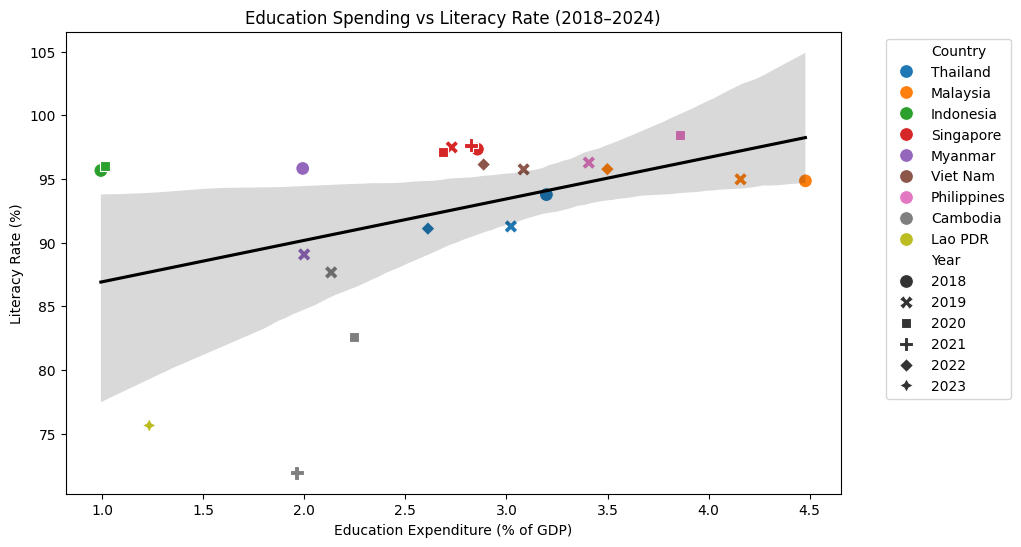

In [18]:
#Biểu đồ 1 : Giáo dục và Literacy (Scatter + Regression)
# Ép kiểu về số
edu_lit["Education_Expenditure"] = pd.to_numeric(edu_lit["Education_Expenditure"], errors='coerce')
edu_lit["Literacy_Rate"] = pd.to_numeric(edu_lit["Literacy_Rate"], errors='coerce')

# Xóa giá trị lỗi/null
edu_lit = edu_lit.dropna()

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=edu_lit,
    x="Education_Expenditure",
    y="Literacy_Rate",
    hue="Country",
    style="Year",
    s=100
)
    
sns.regplot(
    data=edu_lit,
    x="Education_Expenditure",
    y="Literacy_Rate",
    scatter=False,
    color="black"
)

plt.title("Education Spending vs Literacy Rate (2018–2024)")
plt.xlabel("Education Expenditure (% of GDP)")
plt.ylabel("Literacy Rate (%)")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

👉 Nhận xét:
- Biểu đồ cho thấy tồn tại mối tương quan dương giữa chi tiêu cho giáo dục và tỷ lệ biết chữ. Các quốc gia có mức đầu tư cao (khoảng 3%–4.5% GDP) thường đạt tỷ lệ biết chữ cao (trên 94%), trong khi các quốc gia chi tiêu thấp hơn có xu hướng đạt mức thấp hơn và biến động lớn hơn.
- Tuy nhiên, một số ngoại lệ cho thấy tỷ lệ biết chữ không chỉ phụ thuộc vào mức chi tiêu mà còn chịu ảnh hưởng bởi các yếu tố khác như chính sách và hiệu quả quản lý giáo dục. Sự phân tán dữ liệu quanh đường hồi quy cho thấy mối quan hệ này không hoàn toàn tuyến tính.
=> Đầu tư vào giáo dục có xu hướng mang lại kết quả tích cực về tỷ lệ biết chữ, nhưng hiệu quả còn phụ thuộc vào cách thức sử dụng nguồn lực.

### Câu hỏi 2: Phân tích mối quan hệ giữa chi tiêu y tế và tuổi thọ trung bình của các quốc gia để đánh giá tác động của đầu tư y tế đến sức khỏe dân số.

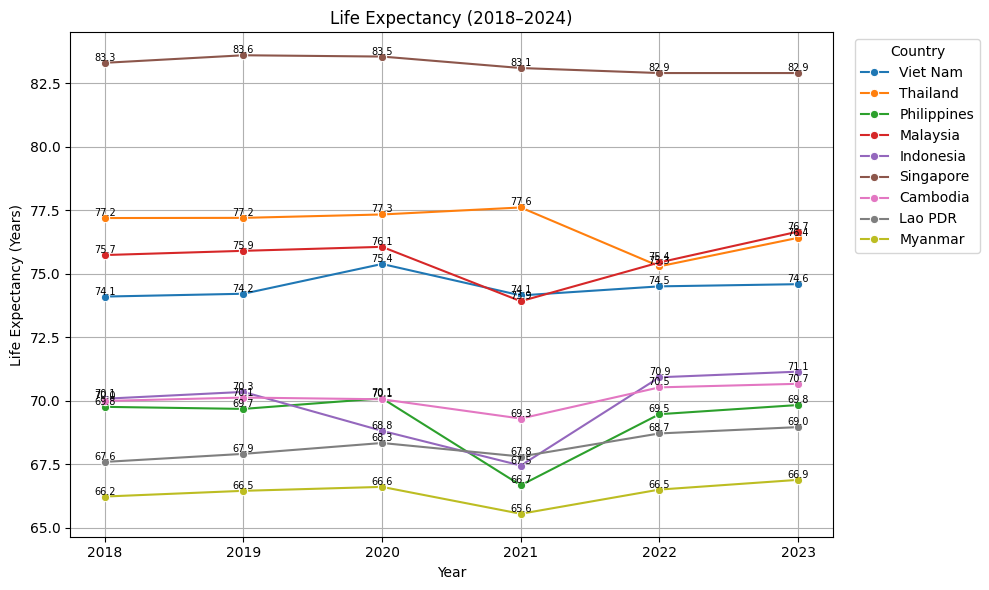

In [19]:
#Biểu đồ thể hiện tuổi thọ trung bình từ 2018 - 2024 của từng nước
plt.figure(figsize=(10,6))

ax = sns.lineplot(
    data=health_life,
    x="Year",
    y="Life_Expectancy",
    hue="Country",
    marker="o"
)

plt.title("Life Expectancy (2018–2024)")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (Years)")
plt.grid()

# 👉 thêm label (chỉ năm cuối cho đỡ rối)
for country in health_life["Country"].unique():
    data = health_life[health_life["Country"] == country].sort_values("Year")
    
    for i in range(len(data)):
        x = data["Year"].iloc[i]
        y = data["Life_Expectancy"].iloc[i]
        
        ax.text(x, y, f"{y:.1f}", fontsize=7, ha='center', va='bottom')
# 👉 legend bên phải
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Country")

plt.tight_layout()
plt.show()

👉 Nhận xét:
- Nhận xét ở đây

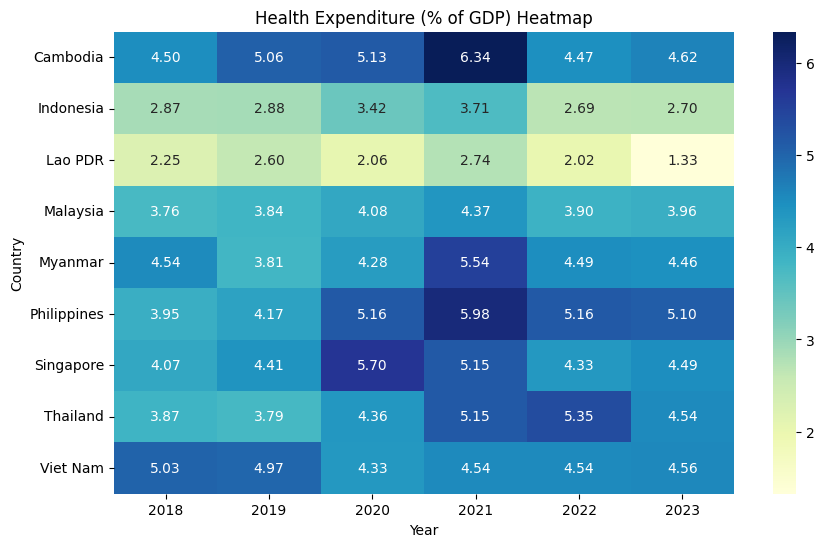

In [20]:
#Biểu đồ chi phí sức khỏe dựa trên %GDP của các nước từ năm 2018 đến 2024
pivot = health_life.pivot(index="Country", columns="Year", values="Health_Expenditure")

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Health Expenditure (% of GDP) Heatmap")
plt.xlabel("Year")
plt.ylabel("Country")

plt.show()

👉 Nhận xét:
- Nhận xét ở đây

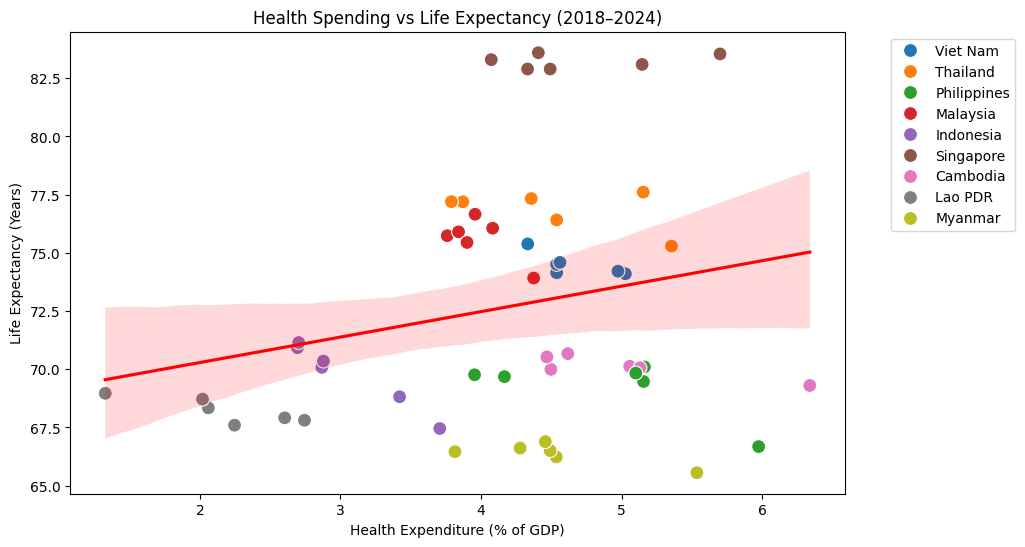

In [21]:
#Biểu đồ 2 : Thể hiện sự liên hệ giữa Chi phí sức khỏe và tuổi thọ trung bình từ năm 2018 đến 2024
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=health_life,
    x="Health_Expenditure",
    y="Life_Expectancy",
    hue="Country",
    s=100
)

sns.regplot(
    data=health_life,
    x="Health_Expenditure",
    y="Life_Expectancy",
    scatter=False,
    color="red"
)

plt.title("Health Spending vs Life Expectancy (2018–2024)")
plt.xlabel("Health Expenditure (% of GDP)")
plt.ylabel("Life Expectancy (Years)")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

👉 Nhận xét:
- Biểu đồ cho thấy tồn tại mối tương quan dương nhẹ giữa chi tiêu y tế (% GDP) và tuổi thọ trung bình. Các quốc gia có mức chi tiêu y tế cao hơn thường đạt tuổi thọ cao hơn, thể hiện qua xu hướng tăng của đường hồi quy.
- Các nước có mức chi tiêu từ khoảng 4%–6% GDP thường có tuổi thọ cao hơn (trên 75 tuổi), trong khi các quốc gia chi tiêu thấp hơn có xu hướng đạt mức tuổi thọ thấp hơn. Tuy nhiên, dữ liệu cũng cho thấy sự phân tán khá lớn giữa các quốc gia.
- Một số trường hợp ngoại lệ (như Singapore có tuổi thọ rất cao dù mức chi tiêu không cao nhất) cho thấy tuổi thọ không chỉ phụ thuộc vào chi tiêu y tế mà còn bị ảnh hưởng bởi các yếu tố khác như chất lượng hệ thống y tế, lối sống và điều kiện kinh tế – xã hội.
=> Đầu tư y tế có tác động tích cực đến tuổi thọ dân số, nhưng mức độ ảnh hưởng không tuyệt đối và phụ thuộc vào hiệu quả sử dụng nguồn lực cũng như các yếu tố liên quan khác.

### Câu hỏi 3: Phân tích xu hướng tỷ lệ tử vong trẻ em theo thời gian tại một số quốc gia đại diện để xem mức cải thiện y tế qua các năm.

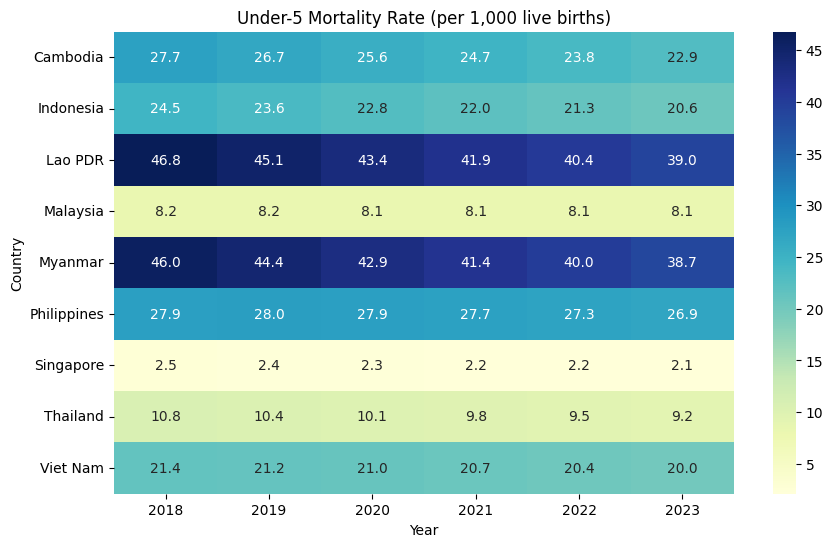

In [22]:
#Biểu đồ 3 : Tỷ lệ tử vong ở trẻ em
mort_df = mort.rename(columns={
    "Country Name": "Country",
    "Value": "Child_Mortality"
}).dropna()

# Pivot
pivot = mort_df.pivot(
    index="Country",
    columns="Year",
    values="Child_Mortality"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Under-5 Mortality Rate (per 1,000 live births)")
plt.xlabel("Year")
plt.ylabel("Country")

plt.show()

👉 Nhận xét:
- Biểu đồ cho thấy xu hướng giảm rõ rệt của tỷ lệ tử vong trẻ em ở hầu hết các quốc gia trong giai đoạn 2018–2023. Điều này phản ánh sự cải thiện tích cực trong hệ thống y tế và chăm sóc sức khỏe.
- Các quốc gia có tỷ lệ tử vong cao như Lào và Myanmar đã ghi nhận mức giảm đáng kể qua các năm, cho thấy những tiến bộ trong việc tiếp cận dịch vụ y tế. Trong khi đó, các quốc gia có tỷ lệ thấp như Singapore và Malaysia duy trì mức ổn định ở ngưỡng rất thấp.
- Ngoài ra, các quốc gia như Việt Nam, Thái Lan và Indonesia cũng cho thấy xu hướng giảm đều, thể hiện sự cải thiện liên tục về điều kiện y tế và chăm sóc trẻ em.
=> Tỷ lệ tử vong trẻ em đang giảm dần theo thời gian, cho thấy những tiến bộ rõ rệt trong lĩnh vực y tế. Tuy nhiên, sự chênh lệch giữa các quốc gia vẫn tồn tại, phản ánh sự khác biệt về mức độ phát triển và chất lượng hệ thống y tế.


## Duy

### Mục tiêu: Phân tích môi trường - năng lượng


In [23]:
### Load dữ liệu ở đây 
# Đọc file Phân tích môi trường – năng lượng Phân tích xu hướng phát thải CO2 của các quốc gia hoặc khu vực trong giai đoạn 2018–2024
file_path_1 = r"C:\Users\admin\data_visualize_lab2\dataDuy.xlsx"
df_1 = pd.read_excel(file_path_1)

print(df_1.head())
print(df_1["Series Name"].unique())

  Country Name Country Code  \
0     Viet Nam          VNM   
1     Viet Nam          VNM   
2     Viet Nam          VNM   
3     Viet Nam          VNM   
4     Thailand          THA   

                                         Series Name           Series Code  \
0  Carbon dioxide (CO2) emissions (total) excludi...  EN.GHG.CO2.MT.CE.AR5   
1  Carbon dioxide (CO2) emissions excluding LULUC...  EN.GHG.CO2.PC.CE.AR5   
2                       GDP per capita (current US$)        NY.GDP.PCAP.CD   
3  Renewable energy consumption (% of total final...        EG.FEC.RNEW.ZS   
4  Carbon dioxide (CO2) emissions (total) excludi...  EN.GHG.CO2.MT.CE.AR5   

   2018 [YR2018]  2019 [YR2019]  2020 [YR2020]  2021 [YR2021] 2022 [YR2022]  \
0     282.097300     336.528800     348.331500     336.170300      343.9999   
1       2.931267       3.463165       3.551533       3.397887       3.45102   
2    3222.310031    3440.900254    3534.039535    3704.193559   4147.697772   
3      24.300000      20.400

In [24]:
#Melt data
df_melt = df_1.melt(
    id_vars=["Country Name", "Series Name"],
    value_vars=[
        "2018 [YR2018]", "2019 [YR2019]", "2020 [YR2020]",
        "2021 [YR2021]", "2022 [YR2022]", "2023 [YR2023]",
        "2024 [YR2024]"
    ],
    var_name="Year",
    value_name="Value"
)

# Lấy năm
df_melt["Year"] = df_melt["Year"].str.extract(r'(\d{4})').astype(int)

# Xóa NaN và data lỗi
df_melt["Value"] = pd.to_numeric(df_melt["Value"], errors='coerce')

df_melt = df_melt.dropna(subset=["Value"])

print(df_melt.head())

  Country Name                                        Series Name  Year  \
0     Viet Nam  Carbon dioxide (CO2) emissions (total) excludi...  2018   
1     Viet Nam  Carbon dioxide (CO2) emissions excluding LULUC...  2018   
2     Viet Nam                       GDP per capita (current US$)  2018   
3     Viet Nam  Renewable energy consumption (% of total final...  2018   
4     Thailand  Carbon dioxide (CO2) emissions (total) excludi...  2018   

         Value  
0   282.097300  
1     2.931267  
2  3222.310031  
3    24.300000  
4   276.653700  


### Câu hỏi 1: Phân tích xu hướng phát thải CO2 của các quốc gia hoặc khu vực trong giai đoạn 2018–2024 để xác định nơi gia tăng phát thải mạnh nhất.

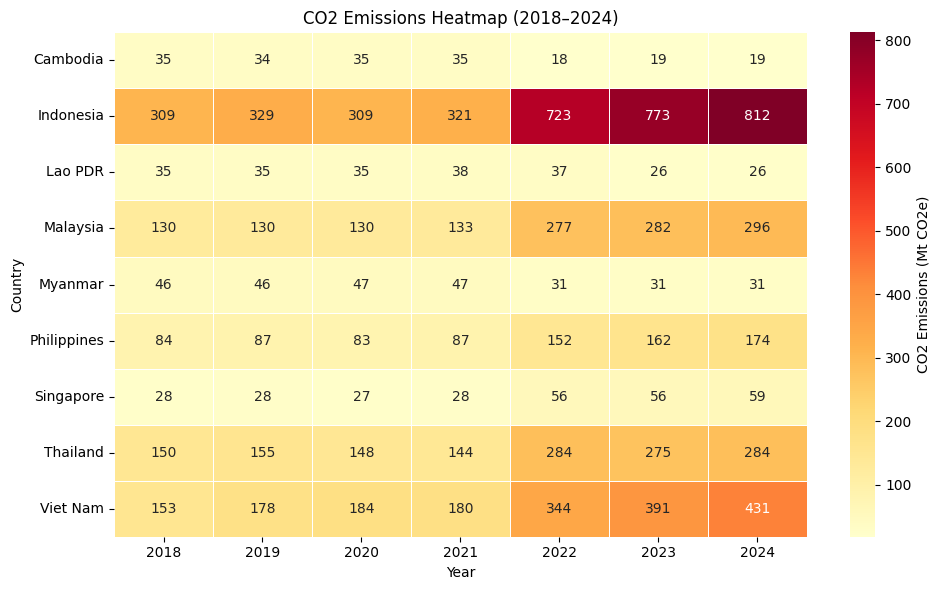

In [25]:
    #Graph 1 : Xu hướng CO2 theo thời gian 
# Lọc CO2 total
co2_total = df_melt[
    df_melt["Series Name"].str.contains("total", case=False, na=False)
]

heatmap_data = co2_total.pivot_table(
    index="Country Name",
    columns="Year",
    values="Value"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={'label': 'CO2 Emissions (Mt CO2e)'}
)

plt.title("CO2 Emissions Heatmap (2018–2024)")
plt.xlabel("Year")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

👉 Nhận xét:
- Biểu đồ cho thấy xu hướng gia tăng phát thải CO₂ rõ rệt ở một số quốc gia trong giai đoạn 2018–2024. Đặc biệt, Indonesia và Việt Nam ghi nhận mức tăng mạnh nhất, với lượng phát thải tăng đáng kể qua các năm, nhất là từ sau năm 2021.
- Malaysia, Thái Lan và Philippines cũng có xu hướng tăng nhưng ở mức độ vừa phải hơn. Trong khi đó, các quốc gia như Lào, Myanmar và Campuchia duy trì mức phát thải thấp và ít biến động, thậm chí có xu hướng giảm nhẹ ở một số năm.
- Đáng chú ý, Singapore dù có mức phát thải thấp hơn so với các quốc gia lớn nhưng vẫn có xu hướng tăng nhẹ theo thời gian.
=> Indonesia và Việt Nam là hai quốc gia có mức gia tăng phát thải CO₂ mạnh nhất trong giai đoạn này. Xu hướng này phản ánh quá trình phát triển kinh tế và công nghiệp hóa, đồng thời đặt ra thách thức về phát triển bền vững và kiểm soát môi trường.

### Câu hỏi 2: Phân tích mối quan hệ giữa GDP bình quân đầu người và phát thải CO2 bình quân đầu người để xem tăng trưởng kinh tế có đi kèm áp lực môi trường hay không.

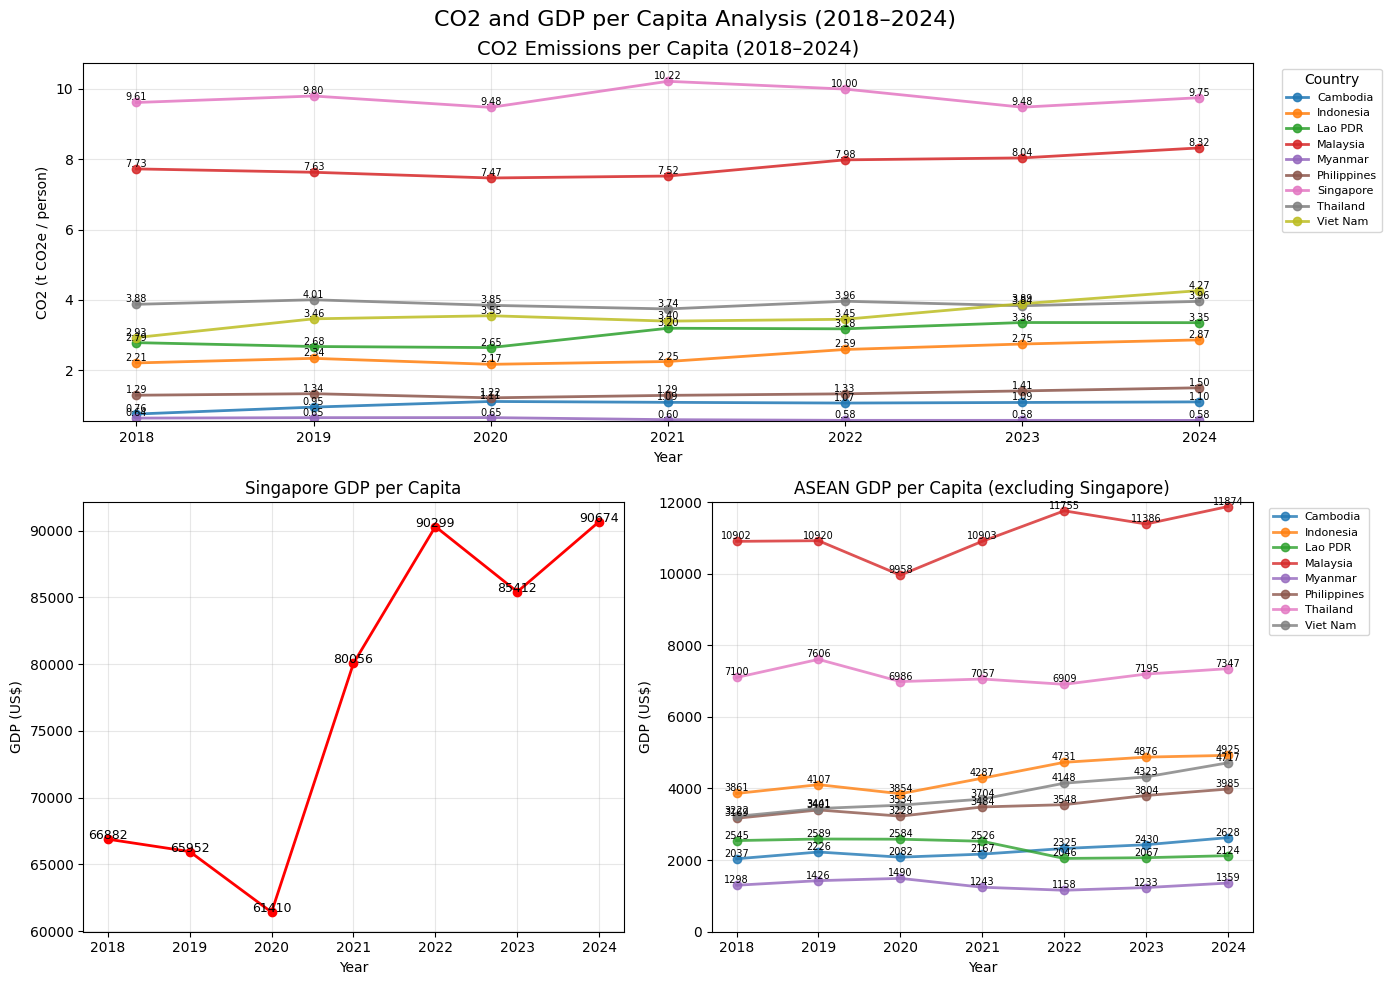

In [28]:
# TẠO merged

co2_pc = df_melt[
    df_melt["Series Name"].str.contains("per capita", na=False) &
    df_melt["Series Name"].str.contains("CO2", na=False)
]

gdp_pc = df_melt[
    df_melt["Series Name"].str.contains("GDP per capita", na=False)
]

merged = pd.merge(
    co2_pc,
    gdp_pc,
    on=["Country Name", "Year"],
    suffixes=("_co2", "_gdp")
)

merged = merged.sort_values(["Country Name", "Year"])

countries = merged["Country Name"].unique()

# TÁCH DỮ LIỆU
data_sg = merged[merged["Country Name"] == "Singapore"]
data_asean = merged[merged["Country Name"] != "Singapore"]

# TẠO LAYOUT
fig = plt.figure(figsize=(14,10))

# Grid: 2 hàng
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

ax_co2 = fig.add_subplot(gs[0, :])     # CO2 full width
ax_gdp_sg = fig.add_subplot(gs[1, 0])  # GDP Singapore
ax_gdp_asean = fig.add_subplot(gs[1, 1])  # GDP ASEAN

# 1. CO2 PER CAPITA
for country in countries:
    temp = merged[merged["Country Name"] == country].sort_values("Year")

    ax_co2.plot(
        temp["Year"],
        temp["Value_co2"],
        marker='o',
        linewidth=2,
        alpha=0.85,
        label=country
    )

    for _, row in temp.iterrows():
        ax_co2.text(
            row["Year"],
            row["Value_co2"],
            f"{row['Value_co2']:.2f}",
            fontsize=7,
            ha='center',
            va='bottom'
        )

# Zoom scale CO2
y_min = merged["Value_co2"].min()
y_max = merged["Value_co2"].max()
ax_co2.set_ylim(y_min * 0.95, y_max * 1.05)

ax_co2.set_title("CO2 Emissions per Capita (2018–2024)", fontsize=14)
ax_co2.set_xlabel("Year")
ax_co2.set_ylabel("CO2 (t CO2e / person)")
ax_co2.grid(alpha=0.3)

ax_co2.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=8,
    title="Country"
)

# 2. GDP - SINGAPORE
temp = data_sg.sort_values("Year")

ax_gdp_sg.plot(
    temp["Year"],
    temp["Value_gdp"],
    marker='o',
    linewidth=2,
    color='red'
)

for _, row in temp.iterrows():
    ax_gdp_sg.text(
        row["Year"],
        row["Value_gdp"],
        f"{row['Value_gdp']:.0f}",
        fontsize=9,
        ha='center'
    )

ax_gdp_sg.set_title("Singapore GDP per Capita")
ax_gdp_sg.set_xlabel("Year")
ax_gdp_sg.set_ylabel("GDP (US$)")
ax_gdp_sg.grid(alpha=0.3)

# 3. GDP - ASEAN
for country in data_asean["Country Name"].unique():
    temp = data_asean[data_asean["Country Name"] == country].sort_values("Year")

    ax_gdp_asean.plot(
        temp["Year"],
        temp["Value_gdp"],
        marker='o',
        linewidth=2,
        alpha=0.8,
        label=country
    )

    for _, row in temp.iterrows():
        ax_gdp_asean.text(
            row["Year"],
            row["Value_gdp"],
            f"{row['Value_gdp']:.0f}",
            fontsize=7,
            ha='center',
            va='bottom'
        )

# Zoom ASEAN
ax_gdp_asean.set_ylim(0, 12000)

ax_gdp_asean.set_title("ASEAN GDP per Capita (excluding Singapore)")
ax_gdp_asean.set_xlabel("Year")
ax_gdp_asean.set_ylabel("GDP (US$)")
ax_gdp_asean.grid(alpha=0.3)

ax_gdp_asean.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=8
)

plt.suptitle("CO2 and GDP per Capita Analysis (2018–2024)", fontsize=16)

plt.tight_layout()
plt.show()

👉 Nhận xét:
- Mối quan hệ giữa GDP bình quân đầu người và phát thải CO₂ bình quân đầu người trong giai đoạn 2018–2024 cho thấy xu hướng đồng biến khá rõ rệt. Ở phần lớn các quốc gia ASEAN như Việt Nam, Indonesia hay Philippines, khi GDP/người tăng lên thì lượng CO₂/người cũng tăng theo, phản ánh quá trình mở rộng sản xuất, công nghiệp hóa và gia tăng tiêu thụ năng lượng. Điều này cho thấy tăng trưởng kinh tế trong giai đoạn đầu thường đi kèm với áp lực môi trường ngày càng lớn.
- Tuy nhiên, mối quan hệ này không hoàn toàn tuyến tính. Trường hợp của Singapore cho thấy dù GDP/người ở mức rất cao nhưng phát thải CO₂ chỉ dao động nhẹ và có xu hướng ổn định. Điều này gợi ý rằng ở các nền kinh tế phát triển hơn, việc ứng dụng công nghệ sạch và chính sách kiểm soát môi trường có thể giúp hạn chế gia tăng phát thải.
=> Tăng trưởng kinh tế tại ASEAN hiện nay vẫn chủ yếu đi kèm với gia tăng phát thải CO₂, đặc biệt ở các nước đang phát triển. Tuy nhiên, về dài hạn, vẫn tồn tại khả năng giảm bớt sự phụ thuộc này nếu các quốc gia chuyển sang mô hình tăng trưởng bền vững hơn.

### Câu hỏi 3: Phân tích tỷ lệ sử dụng năng lượng tái tạo giữa các quốc gi trong năm gần nhất để xác định nhóm nước chuyển đổi xanh tốt hơn.

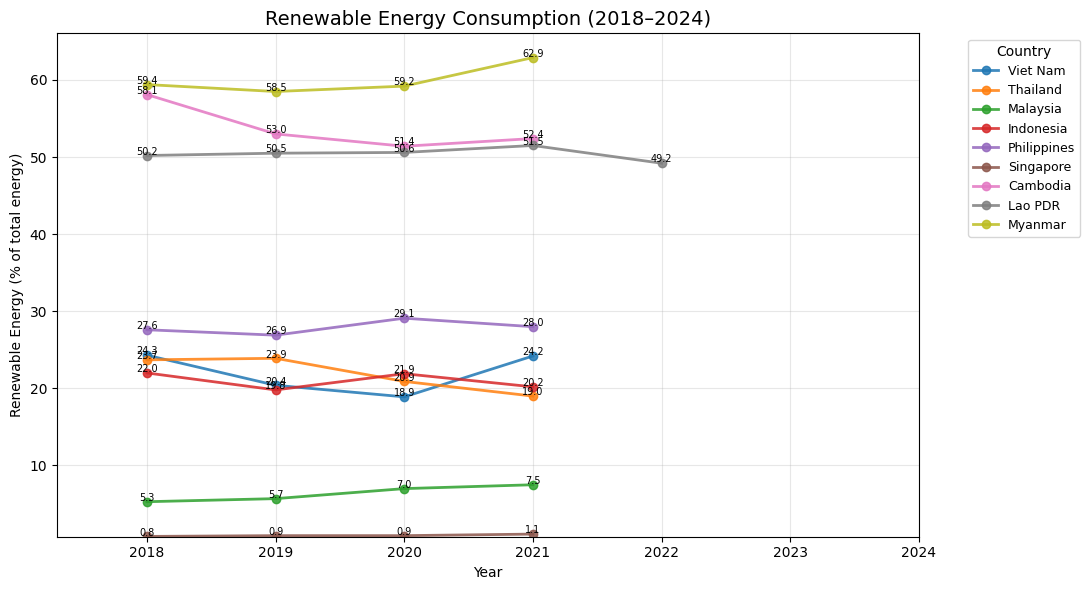

In [30]:
#Lọc renewable energy
renew = df_melt[
    df_melt["Series Name"].str.lower().str.contains("renewable", na=False)
].copy()

renew["Year"] = renew["Year"].astype(int)
renew = renew.dropna(subset=["Value"])

plt.figure(figsize=(11,6))

for country in renew["Country Name"].unique():
    temp = renew[renew["Country Name"] == country].sort_values("Year")

    plt.plot(
        temp["Year"],
        temp["Value"],
        marker='o',
        linewidth=2,
        alpha=0.85,
        label=country
    )

    for _, row in temp.iterrows():
        plt.text(
            row["Year"],
            row["Value"] + 0.1,              
            f"{row['Value']:.1f}",           
            fontsize=7,
            ha='center'
        )

plt.xticks(range(2018, 2025))
plt.xlim(2017.3, 2024)

y_min = renew["Value"].min()
y_max = renew["Value"].max()
plt.ylim(y_min * 0.95, y_max * 1.05)

plt.title("Renewable Energy Consumption (2018–2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Renewable Energy (% of total energy)")

plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=9,
    title="Country"
)

plt.tight_layout()
plt.show()

👉 Nhận xét:
- Dựa trên số liệu năm gần nhất, có thể thấy sự khác biệt rõ rệt về tỷ lệ sử dụng năng lượng tái tạo giữa các quốc gia ASEAN. Nhóm nước như Myanmar, Campuchia và Lào có tỷ lệ rất cao (khoảng 50–60%), cho thấy mức độ sử dụng năng lượng tái tạo vượt trội, chủ yếu nhờ vào nguồn thủy điện và sinh khối.
- Các quốc gia như Việt Nam, Philippines, Thái Lan và Indonesia nằm ở mức trung bình (khoảng 20–30%), phản ánh quá trình chuyển đổi năng lượng đang diễn ra nhưng vẫn phụ thuộc một phần vào nhiên liệu hóa thạch.
- Malaysia và Singapore có tỷ lệ rất thấp (dưới 10%), cho thấy quá trình chuyển đổi xanh còn chậm và phụ thuộc nhiều vào nguồn năng lượng truyền thống.
=> Các quốc gia có tỷ lệ năng lượng tái tạo cao thường là những nước có điều kiện tự nhiên thuận lợi hoặc mức độ công nghiệp hóa chưa cao, trong khi các nền kinh tế phát triển hơn lại gặp nhiều thách thức trong việc chuyển đổi nhanh sang năng lượng sạch. Điều này cho thấy quá trình chuyển đổi xanh trong khu vực ASEAN còn chưa đồng đều và phụ thuộc vào cả yếu tố kinh tế lẫn tài nguyên.


## Lộc

### Mục tiêu: Phân tích tổng hợp và khám phá quan hệ chỉ số


In [ ]:
### Load dữ liệu ở đây

In [ ]:
### Tiền xử lý dữ liệu ở đây (nếu có) 

### Câu hỏi 1: Phân tích tương quan giữa nhiều chỉ số phát triển quan trọng như GDP/người, tuổi thọ, tỷ lệ đô thị hóa, phát thải CO2, chi tiêu giáo dục để tìm các mối quan hệ nổi bật.

In [ ]:
### Code biểu đồ ở đây

👉 Nhận xét:
- Nhận xét ở đây

### Câu hỏi 2: Phân cụm hoặc phân nhóm mô tả các quốc gia theo bộ chỉ số phát triển chính trong năm 2024 để nhận diện các nhóm quốc gia có đặc điểm tương đồng.

In [ ]:
### Code biểu đồ ở đây 

👉 Nhận xét:
- Nhận xét ở đây

### Câu hỏi 3: Xác định các quốc gia có sự thay đổi mạnh nhất về chỉ số phát triển trong giai đoạn 2018-2024 để rút ra những trường hợp điển hình về tăng trưởng hoặc suy giảm.

In [ ]:
### Code biểu đồ ở đây

👉 Nhận xét:
- Nhận xét ở đây